In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Chennai_Raw_Data.csv')
df['Date'] = pd.to_datetime(df['Date'])

In [3]:
print(f'Shape        : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date Range   : {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Locations    : {df["Location"].nunique()} junctions')
print(f'Total Days   : {df["Date"].nunique()} days')
df.head()

Shape        : 17,472 rows x 19 columns
Date Range   : 2024-01-01 to 2024-06-30
Locations    : 4 junctions
Total Days   : 182 days


,Date,Day_of_Week,Day_Type,Month,Hour,Time_Slot,Time_Period,Location,Event_Note,Two_Wheelers,Cars_and_SUVs,Auto_Rickshaws,Buses_MTC_Private,Trucks_and_LCVs,Total_Vehicles,PCU_Value,Avg_Speed_kmph,Signal_Delay_sec,Congestion_Level
0,2024-01-01,Monday,Weekday,January,0,00:00-01:00,Night,Kathipara Junction,Regular Day,48,40,7,9,14,118,137.2,31.7,21.2,Free Flow
1,2024-01-01,Monday,Weekday,January,1,01:00-02:00,Night,Kathipara Junction,Regular Day,14,11,3,2,0,30,25.8,31.4,15.6,Free Flow
2,2024-01-01,Monday,Weekday,January,2,02:00-03:00,Night,Kathipara Junction,Regular Day,54,53,9,8,8,132,133.4,35.6,23.6,Free Flow
3,2024-01-01,Monday,Weekday,January,3,03:00-04:00,Night,Kathipara Junction,Regular Day,42,34,9,6,8,99,102.4,36.6,17.2,Free Flow
4,2024-01-01,Monday,Weekday,January,4,04:00-05:00,Night,Kathipara Junction,Regular Day,65,55,9,11,15,155,170.9,36.7,15.0,Free Flow


In [4]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())

--- Data Types ---
Date                 datetime64[ns]
Day_of_Week                  object
Day_Type                     object
Month                        object
Hour                          int64
Time_Slot                    object
Time_Period                  object
Location                     object
Event_Note                   object
Two_Wheelers                  int64
Cars_and_SUVs                 int64
Auto_Rickshaws                int64
Buses_MTC_Private             int64
Trucks_and_LCVs               int64
Total_Vehicles                int64
PCU_Value                   float64
Avg_Speed_kmph              float64
Signal_Delay_sec            float64
Congestion_Level             object
dtype: object

--- Missing Values ---
Date                 0
Day_of_Week          0
Day_Type             0
Month                0
Hour                 0
Time_Slot            0
Time_Period          0
Location             0
Event_Note           0
Two_Wheelers         0
Cars_and_SUVs        0
Auto_R

In [5]:
key_cols = ['Total_Vehicles', 'PCU_Value', 'Avg_Speed_kmph', 'Signal_Delay_sec']
df[key_cols].describe().round(2)

,Total_Vehicles,PCU_Value,Avg_Speed_kmph,Signal_Delay_sec
count,17472.00,17472.00,17472.00,17472.00
mean,695.60,704.32,23.54,76.22
std,562.08,573.61,7.75,52.12
min,9.00,6.50,10.00,10.00
25%,155.00,155.90,16.90,26.50
50%,637.00,639.00,23.00,71.00
75%,1007.00,1023.50,30.10,121.40
max,2554.00,2757.80,38.00,189.70


In [6]:
df.groupby('Location')['Total_Vehicles'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Location,,,,,,,,
Kathipara Junction,4368.0,755.31,611.92,9.0,172.00,695.5,1036.00,2554.0
Koyambedu Junction,4368.0,696.45,563.26,12.0,157.75,644.5,971.25,2333.0
Porur Junction,4368.0,640.83,515.58,9.0,144.00,588.0,910.00,2325.0
T. Nagar (Panagal Park),4368.0,689.81,547.55,11.0,149.00,634.0,1081.50,2205.0


In [7]:
cong_counts = df['Congestion_Level'].value_counts()
cong_pct    = (cong_counts / len(df) * 100).round(2)

cong_summary = pd.DataFrame({'Count': cong_counts, 'Percentage (%)': cong_pct})
print(cong_summary)

                  Count  Percentage (%)
Congestion_Level                       
Severe             6339           36.28
Free Flow          6301           36.06
Moderate           1876           10.74
Light              1724            9.87
Heavy              1232            7.05


In [8]:
hourly_avg = df.groupby('Hour')['Total_Vehicles'].mean().round(1).reset_index()
hourly_avg.columns = ['Hour', 'Avg_Vehicles_per_Hour']
print(hourly_avg.to_string(index=False))

 Hour  Avg_Vehicles_per_Hour
    0                   98.8
    1                  101.2
    2                   96.2
    3                   99.6
    4                   98.5
    5                   98.0
    6                  301.4
    7                  541.0
    8                 1320.0
    9                 1318.8
   10                 1327.6
   11                  758.8
   12                  765.1
   13                  755.0
   14                  755.8
   15                  760.4
   16                  754.7
   17                 1447.8
   18                 1443.3
   19                 1454.7
   20                 1454.6
   21                  543.9
   22                  299.1
   23                  100.0


In [9]:
day_type_summary = df.groupby('Day_Type')[['Total_Vehicles','Avg_Speed_kmph','Signal_Delay_sec']].describe().round(2)
print(day_type_summary)

         Total_Vehicles                                                      \
                  count    mean     std   min    25%    50%     75%     max   
Day_Type                                                                      
Weekday         12480.0  740.01  611.65   9.0  156.0  633.0  1278.0  2554.0   
Weekend          4992.0  584.58  391.48  11.0  153.0  647.5   907.0  1553.0   

         Avg_Speed_kmph         ...             Signal_Delay_sec         \
                  count   mean  ...   75%   max            count   mean   
Day_Type                        ...                                       
Weekday         12480.0  23.53  ...  30.1  38.0          12480.0  76.17   
Weekend          4992.0  23.57  ...  30.2  38.0           4992.0  76.34   

                                                 
            std   min   25%   50%    75%    max  
Day_Type                                         
Weekday   52.22  10.0  26.5  70.5  122.9  189.7  
Weekend   51.88  10.0  26.5 

In [10]:
month_order = ['January','February','March','April','May','June']
monthly = df.groupby('Month')[['Total_Vehicles','Avg_Speed_kmph','Signal_Delay_sec']].mean().reindex(month_order).round(2)
print(monthly)

          Total_Vehicles  Avg_Speed_kmph  Signal_Delay_sec
Month                                                     
January           684.36           23.57             75.82
February          733.47           23.58             76.40
March             699.65           23.59             76.19
April             723.40           23.41             76.51
May               681.93           23.53             76.22
June              652.74           23.55             76.20


In [11]:
vtype_cols   = ['Two_Wheelers','Cars_and_SUVs','Auto_Rickshaws','Buses_MTC_Private','Trucks_and_LCVs']
vtype_means  = df[vtype_cols].mean().round(1)
vtype_share  = (vtype_means / vtype_means.sum() * 100).round(2)

vtype_df = pd.DataFrame({'Avg per Hour': vtype_means, 'Share (%)': vtype_share})
print(vtype_df)

                   Avg per Hour  Share (%)
Two_Wheelers              299.5      43.06
Cars_and_SUVs             250.6      36.03
Auto_Rickshaws             55.2       7.94
Buses_MTC_Private          48.3       6.94
Trucks_and_LCVs            42.0       6.04


In [12]:
peak_df = df[df['Time_Period'].isin(['Morning Peak','Evening Peak']) & (df['Day_Type'] == 'Weekday')]

peak_summary = peak_df.groupby('Location').agg(
    Avg_Arrival_Rate  = ('Total_Vehicles',     'mean'),
    Max_Arrival_Rate  = ('Total_Vehicles',     'max'),
    Avg_Speed_kmph    = ('Avg_Speed_kmph',     'mean'),
    Avg_Signal_Delay  = ('Signal_Delay_sec',   'mean'),
    Avg_PCU           = ('PCU_Value',          'mean')
).round(2)

print(peak_summary)

                         Avg_Arrival_Rate  Max_Arrival_Rate  Avg_Speed_kmph  \
Location                                                                      
Kathipara Junction                1732.84              2554           14.34   
Koyambedu Junction                1592.26              2333           14.33   
Porur Junction                    1454.54              2325           14.35   
T. Nagar (Panagal Park)           1508.28              2205           14.39   

                         Avg_Signal_Delay  Avg_PCU  
Location                                            
Kathipara Junction                 146.04  1753.71  
Koyambedu Junction                 146.36  1617.51  
Porur Junction                     146.61  1474.44  
T. Nagar (Panagal Park)            147.38  1527.70  


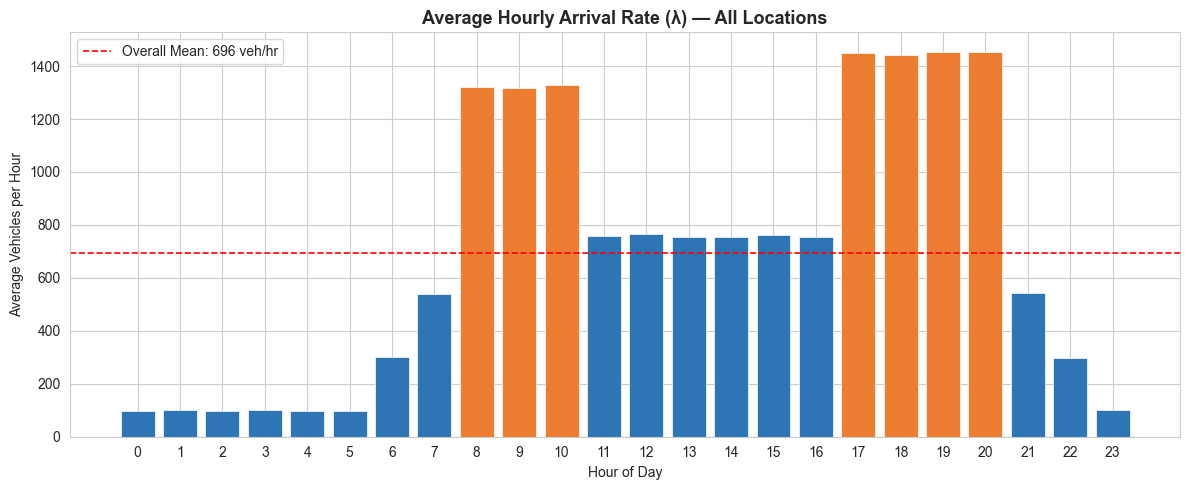

In [13]:
palette = ['#1F3864','#2E75B6','#70AD47','#ED7D31','#FFC000']
sns.set_style('whitegrid')

hourly = df.groupby('Hour')['Total_Vehicles'].mean()
colors = ['#ED7D31' if (8 <= h <= 10 or 17 <= h <= 20) else '#2E75B6' for h in hourly.index]

plt.figure(figsize=(12, 5))
plt.bar(hourly.index, hourly.values, color=colors, edgecolor='white', linewidth=0.5)
plt.axhline(hourly.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Overall Mean: {hourly.mean():.0f} veh/hr')
plt.title('Average Hourly Arrival Rate (λ) — All Locations', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Average Vehicles per Hour')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

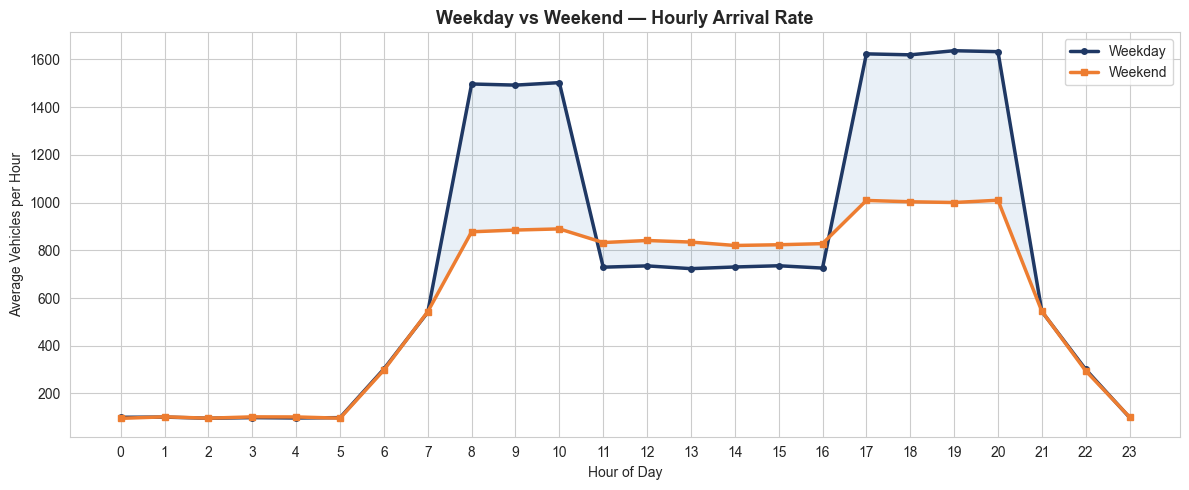

In [14]:
wd = df[df['Day_Type'] == 'Weekday'].groupby('Hour')['Total_Vehicles'].mean()
we = df[df['Day_Type'] == 'Weekend'].groupby('Hour')['Total_Vehicles'].mean()

plt.figure(figsize=(12, 5))
plt.plot(wd.index, wd.values, color='#1F3864', linewidth=2.5, marker='o', markersize=4, label='Weekday')
plt.plot(we.index, we.values, color='#ED7D31', linewidth=2.5, marker='s', markersize=4, label='Weekend')
plt.fill_between(wd.index, wd.values, we.values, alpha=0.1, color='#2E75B6')
plt.title('Weekday vs Weekend — Hourly Arrival Rate', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Average Vehicles per Hour')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

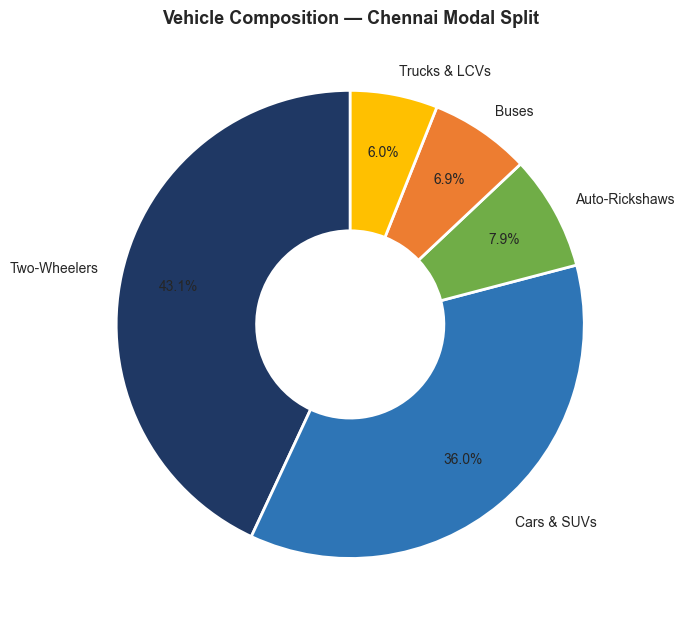

In [15]:
vtype_cols   = ['Two_Wheelers','Cars_and_SUVs','Auto_Rickshaws','Buses_MTC_Private','Trucks_and_LCVs']
vtype_labels = ['Two-Wheelers','Cars & SUVs','Auto-Rickshaws','Buses','Trucks & LCVs']
vtype_means  = [df[c].mean() for c in vtype_cols]

plt.figure(figsize=(7, 7))
wedge_props = dict(width=0.6, edgecolor='white', linewidth=2)
plt.pie(vtype_means, labels=vtype_labels, autopct='%1.1f%%',
        colors=palette, wedgeprops=wedge_props, startangle=90, pctdistance=0.75)
plt.title('Vehicle Composition — Chennai Modal Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

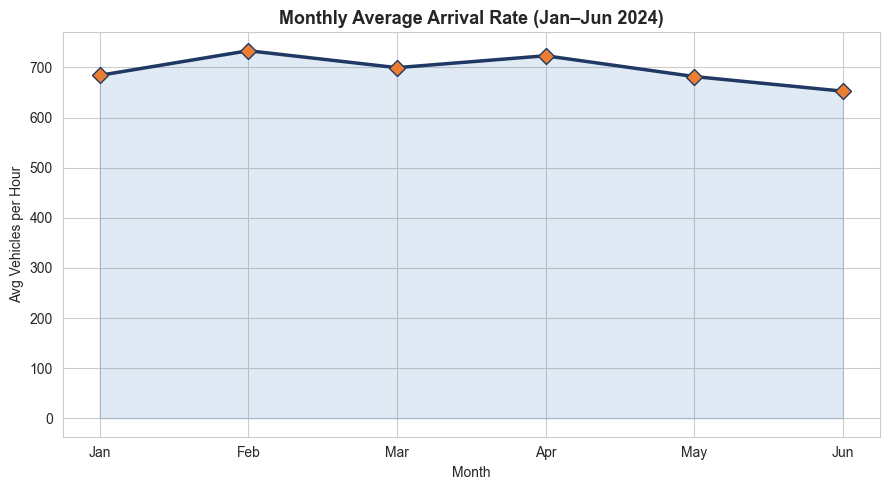

In [16]:
month_order = ['January','February','March','April','May','June']
monthly     = df.groupby('Month')['Total_Vehicles'].mean().reindex(month_order)

plt.figure(figsize=(9, 5))
plt.plot(range(len(month_order)), monthly.values, color='#1F3864', linewidth=2.5,
         marker='D', markersize=8, markerfacecolor='#ED7D31')
plt.fill_between(range(len(month_order)), monthly.values, alpha=0.15, color='#2E75B6')
plt.xticks(range(len(month_order)), ['Jan','Feb','Mar','Apr','May','Jun'])
plt.title('Monthly Average Arrival Rate (Jan–Jun 2024)', fontsize=13, fontweight='bold')
plt.ylabel('Avg Vehicles per Hour')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

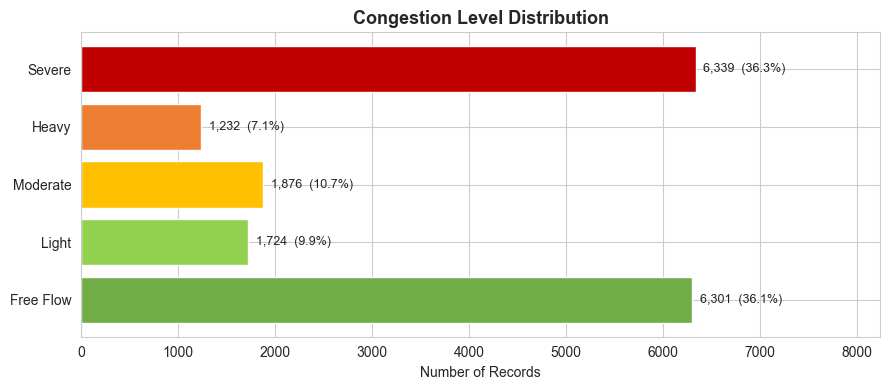

In [17]:
cong_order  = ['Free Flow','Light','Moderate','Heavy','Severe']
cong_colors = ['#70AD47','#92D050','#FFC000','#ED7D31','#C00000']
cong_counts = df['Congestion_Level'].value_counts().reindex(cong_order)

plt.figure(figsize=(9, 4))
bars = plt.barh(cong_order, cong_counts.values, color=cong_colors, edgecolor='white')
for bar, val in zip(bars, cong_counts.values):
    plt.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
             f'{val:,}  ({100*val/len(df):.1f}%)', va='center', fontsize=9)
plt.title('Congestion Level Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Number of Records')
plt.xlim(0, cong_counts.max() * 1.3)
plt.tight_layout()
plt.show()

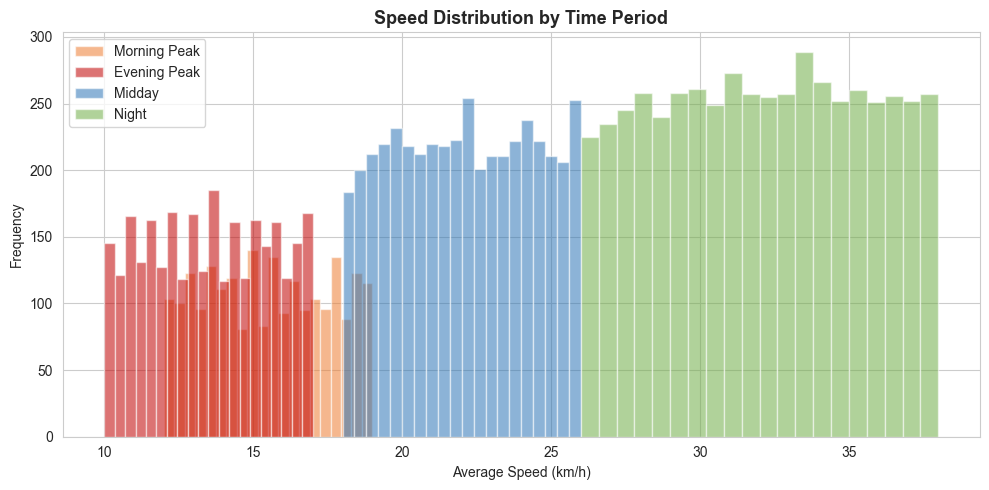

In [18]:
plt.figure(figsize=(10, 5))
for period, color in zip(['Morning Peak','Evening Peak','Midday','Night'],
                          ['#ED7D31','#C00000','#2E75B6','#70AD47']):
    sub = df[df['Time_Period'] == period]['Avg_Speed_kmph']
    plt.hist(sub, bins=20, alpha=0.55, color=color, label=period, edgecolor='white')
plt.title('Speed Distribution by Time Period', fontsize=13, fontweight='bold')
plt.xlabel('Average Speed (km/h)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\SUGANESH SP\AppData\Local\Temp\ipykernel_23932\2179758433.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=peak_df, x='Loc_Short', y='Total_Vehicles',


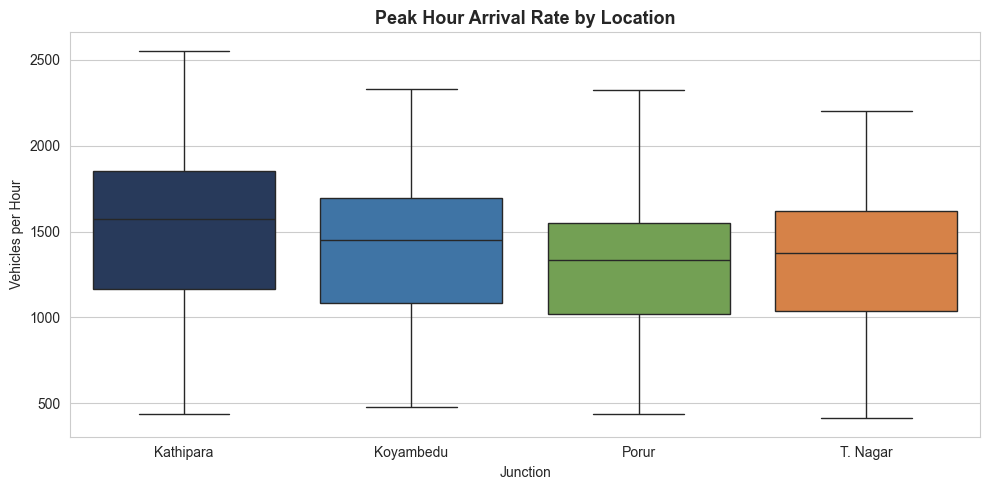

In [19]:
loc_short = {
    'Kathipara Junction':      'Kathipara',
    'Koyambedu Junction':      'Koyambedu',
    'Porur Junction':          'Porur',
    'T. Nagar (Panagal Park)': 'T. Nagar'
}
df['Loc_Short'] = df['Location'].map(loc_short)
peak_df = df[df['Time_Period'].isin(['Morning Peak','Evening Peak'])]

plt.figure(figsize=(10, 5))
sns.boxplot(data=peak_df, x='Loc_Short', y='Total_Vehicles',
            palette=['#1F3864','#2E75B6','#70AD47','#ED7D31'])
plt.title('Peak Hour Arrival Rate by Location', fontsize=13, fontweight='bold')
plt.xlabel('Junction')
plt.ylabel('Vehicles per Hour')
plt.tight_layout()
plt.show()

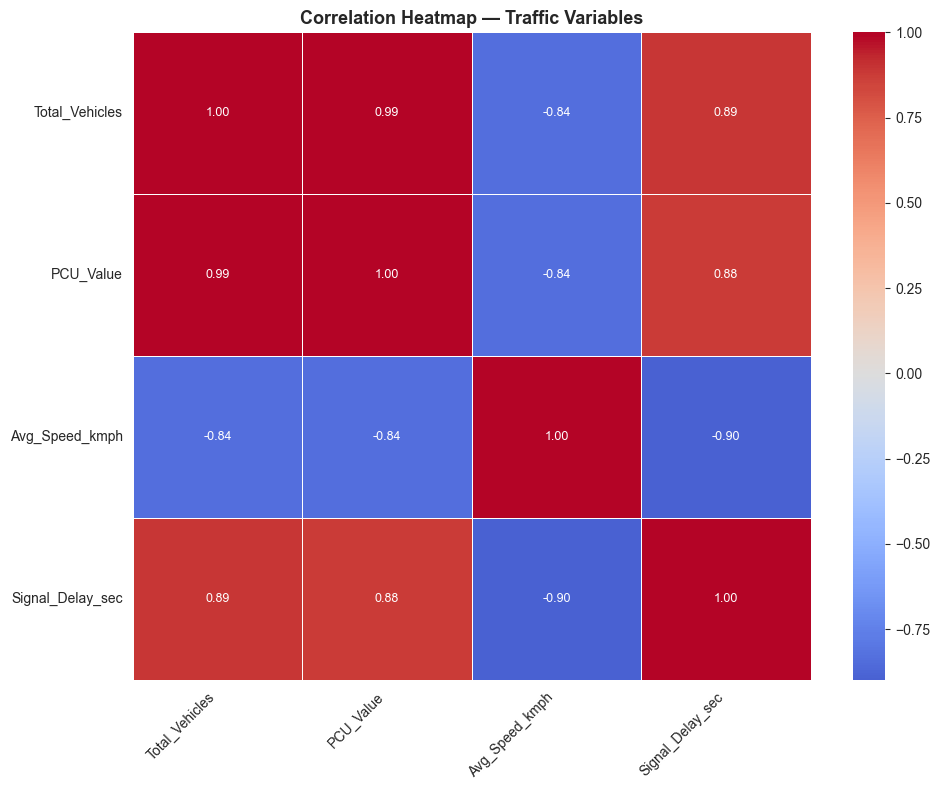


Top Correlations with Total_Vehicles:
PCU_Value           0.99
Signal_Delay_sec    0.89
Avg_Speed_kmph     -0.84
Name: Total_Vehicles, dtype: float64


In [20]:
# Remove vehicle sub-types — only keep meaningful variables
numeric_cols = ['Total_Vehicles', 'PCU_Value', 
                'Avg_Speed_kmph', 'Signal_Delay_sec']

corr_matrix = df[numeric_cols].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Correlation Heatmap — Traffic Variables', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nTop Correlations with Total_Vehicles:")
corr_tv = corr_matrix['Total_Vehicles'].drop('Total_Vehicles').sort_values(ascending=False)
print(corr_tv)

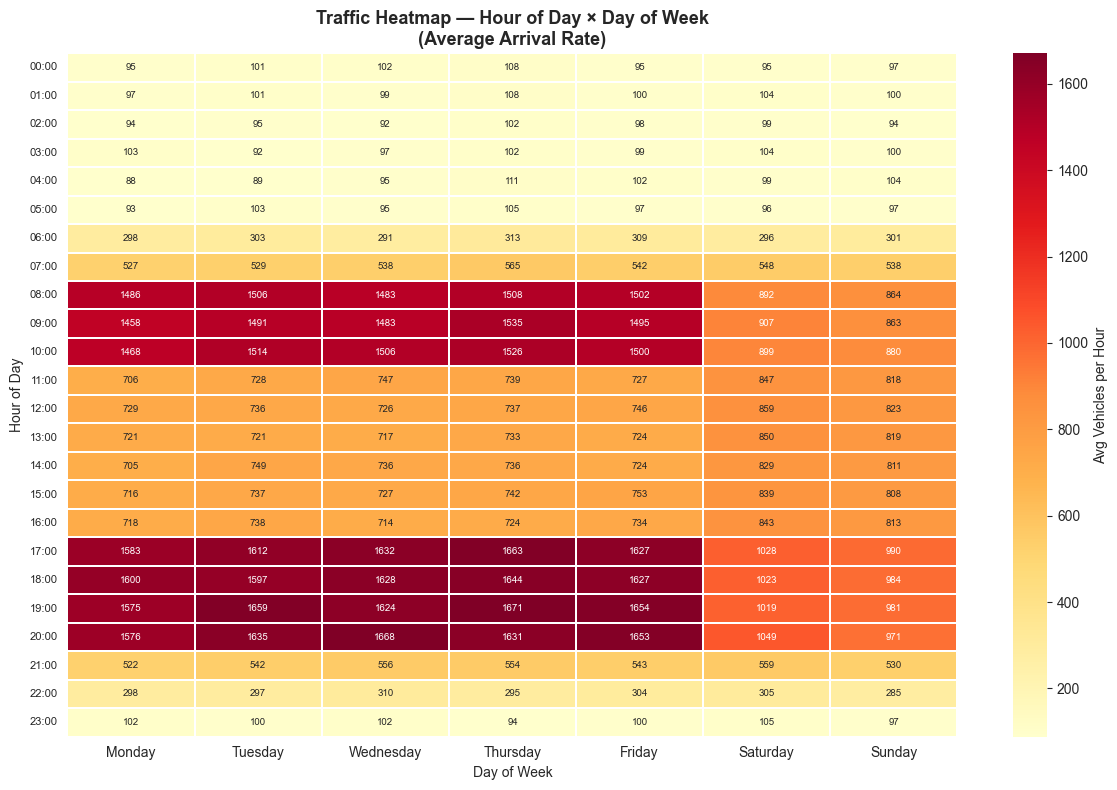

In [21]:
day_order  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

pivot = df.pivot_table(values='Total_Vehicles', 
                        index='Hour', 
                        columns='Day_of_Week', 
                        aggfunc='mean')[day_order]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, 
            cmap='YlOrRd', 
            annot=True, 
            fmt='.0f',
            linewidths=0.3,
            annot_kws={'size': 7},
            cbar_kws={'label': 'Avg Vehicles per Hour'})
plt.title('Traffic Heatmap — Hour of Day × Day of Week\n(Average Arrival Rate)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.yticks(ticks=[h + 0.5 for h in range(24)], 
           labels=[f'{h:02d}:00' for h in range(24)], 
           rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

OUTLIER DETECTION — IQR METHOD
Q1 (25th percentile) : 155.0 veh/hr
Q3 (75th percentile) : 1007.0 veh/hr
IQR                  : 852.0
Lower Bound          : -1123.0 veh/hr
Upper Bound          : 2285.0 veh/hr

Total Records        : 17,472
Outliers Found       : 25  (0.14%)
Clean Records        : 17,447  (99.86%)

Outlier Breakdown by Location:
                    count   min   max    mean
Location                                     
Kathipara Junction     23  2287  2554  2380.3
Koyambedu Junction      1  2333  2333  2333.0
Porur Junction          1  2325  2325  2325.0

Outlier Breakdown by Time Period:
              count   min   max    mean
Time_Period                            
Evening Peak     25  2287  2554  2376.2


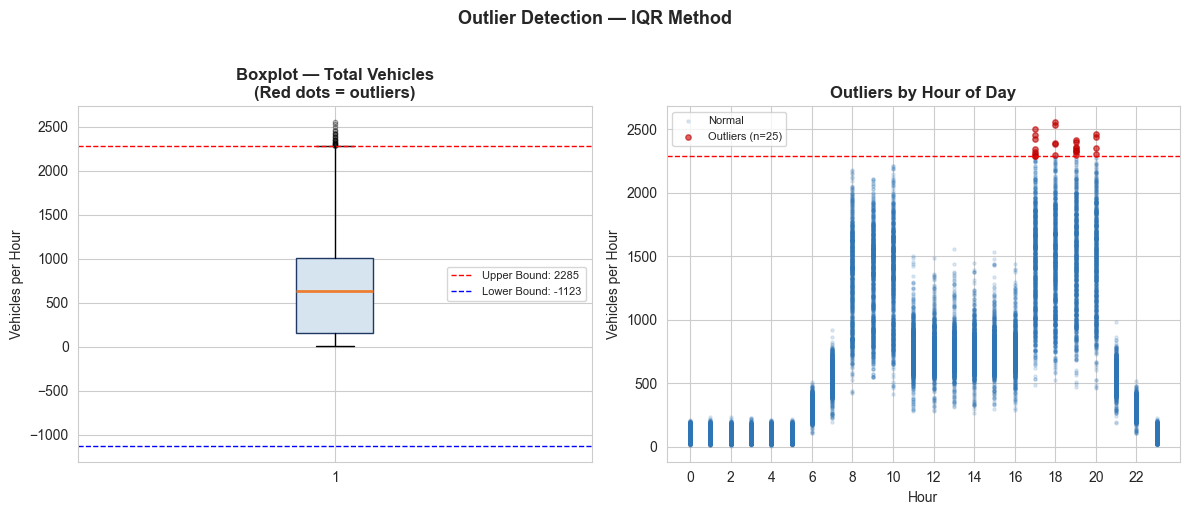

In [22]:
Q1  = df['Total_Vehicles'].quantile(0.25)
Q3  = df['Total_Vehicles'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers    = df[(df['Total_Vehicles'] < lower_bound) | (df['Total_Vehicles'] > upper_bound)]
non_outliers= df[(df['Total_Vehicles'] >= lower_bound) & (df['Total_Vehicles'] <= upper_bound)]

print("=" * 50)
print("OUTLIER DETECTION — IQR METHOD")
print("=" * 50)
print(f"Q1 (25th percentile) : {Q1:.1f} veh/hr")
print(f"Q3 (75th percentile) : {Q3:.1f} veh/hr")
print(f"IQR                  : {IQR:.1f}")
print(f"Lower Bound          : {lower_bound:.1f} veh/hr")
print(f"Upper Bound          : {upper_bound:.1f} veh/hr")
print(f"\nTotal Records        : {len(df):,}")
print(f"Outliers Found       : {len(outliers):,}  ({100*len(outliers)/len(df):.2f}%)")
print(f"Clean Records        : {len(non_outliers):,}  ({100*len(non_outliers)/len(df):.2f}%)")

print("\nOutlier Breakdown by Location:")
print(outliers.groupby('Location')['Total_Vehicles'].agg(['count','min','max','mean']).round(1))

print("\nOutlier Breakdown by Time Period:")
print(outliers.groupby('Time_Period')['Total_Vehicles'].agg(['count','min','max','mean']).round(1))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.boxplot(df['Total_Vehicles'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='#D6E4F0', color='#1F3864'),
            medianprops=dict(color='#ED7D31', linewidth=2),
            flierprops=dict(marker='o', color='#C00000', alpha=0.4, markersize=3))
plt.title('Boxplot — Total Vehicles\n(Red dots = outliers)', fontweight='bold')
plt.ylabel('Vehicles per Hour')
plt.axhline(upper_bound, color='red', linestyle='--', linewidth=1, label=f'Upper Bound: {upper_bound:.0f}')
plt.axhline(lower_bound, color='blue', linestyle='--', linewidth=1, label=f'Lower Bound: {lower_bound:.0f}')
plt.legend(fontsize=8)

# Right: Scatter — outliers highlighted
plt.subplot(1, 2, 2)
plt.scatter(non_outliers['Hour'], non_outliers['Total_Vehicles'], 
            alpha=0.15, color='#2E75B6', s=5, label='Normal')
plt.scatter(outliers['Hour'], outliers['Total_Vehicles'], 
            alpha=0.6, color='#C00000', s=15, label=f'Outliers (n={len(outliers):,})')
plt.axhline(upper_bound, color='red', linestyle='--', linewidth=1)
plt.title('Outliers by Hour of Day', fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('Vehicles per Hour')
plt.xticks(range(0, 24, 2))
plt.legend(fontsize=8)

plt.suptitle('Outlier Detection — IQR Method', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

DISTRIBUTION SHAPE ANALYSIS

Total_Vehicles:
  Skewness : 0.7003  → Right skewed
  Kurtosis : -0.4394  → Normal-like

Avg_Speed_kmph:
  Skewness : 0.1398  → Approx. Symmetric
  Kurtosis : -1.1087  → Light tailed

Signal_Delay_sec:
  Skewness : 0.4761  → Approx. Symmetric
  Kurtosis : -0.9956  → Normal-like

PCU_Value:
  Skewness : 0.7326  → Right skewed
  Kurtosis : -0.3342  → Normal-like


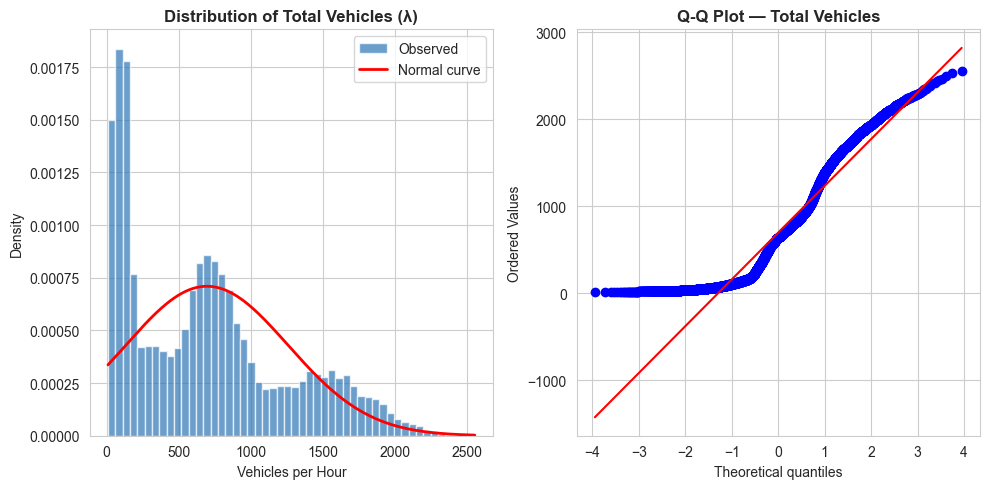

In [23]:
# Distribution shape — Skewness & Kurtosis
from scipy import stats

print("=" * 50)
print("DISTRIBUTION SHAPE ANALYSIS")
print("=" * 50)

for col in ['Total_Vehicles', 'Avg_Speed_kmph', 'Signal_Delay_sec', 'PCU_Value']:
    skew = df[col].skew()
    kurt = df[col].kurt()
    
    skew_label = 'Right skewed' if skew > 0.5 else ('Left skewed' if skew < -0.5 else 'Approx. Symmetric')
    kurt_label = 'Heavy tailed' if kurt > 1 else ('Light tailed' if kurt < -1 else 'Normal-like')
    
    print(f"\n{col}:")
    print(f"  Skewness : {skew:.4f}  → {skew_label}")
    print(f"  Kurtosis : {kurt:.4f}  → {kurt_label}")

# Histogram of Total Vehicles with normal curve overlay
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(df['Total_Vehicles'], bins=50, color='#2E75B6', edgecolor='white', 
         alpha=0.7, density=True, label='Observed')
mu, std = df['Total_Vehicles'].mean(), df['Total_Vehicles'].std()
x = np.linspace(df['Total_Vehicles'].min(), df['Total_Vehicles'].max(), 200)
plt.plot(x, stats.norm.pdf(x, mu, std), color='red', linewidth=2, label='Normal curve')
plt.title('Distribution of Total Vehicles (λ)', fontweight='bold')
plt.xlabel('Vehicles per Hour')
plt.ylabel('Density')
plt.legend()

plt.subplot(1, 2, 2)
stats.probplot(df['Total_Vehicles'], dist="norm", plot=plt)
plt.title('Q-Q Plot — Total Vehicles', fontweight='bold')

plt.tight_layout()
plt.show()

In [24]:
from scipy import stats
from scipy.stats import poisson

time_periods = ['Night', 'Morning Peak', 'Midday', 'Evening Peak']
print("Time periods defined:", time_periods)

In [25]:
results = []

for period in time_periods:
    sub  = df[df['Time_Period'] == period]['Total_Vehicles']
    mean = sub.mean()
    var  = sub.var()
    ID   = var / mean
    results.append({'Time Period': period, 'Mean': round(mean, 2), 
                    'Variance': round(var, 2), 'Index of Dispersion': round(ID, 4)})

dispersion_df = pd.DataFrame(results)
dispersion_df

,Time Period,Mean,Variance,Index of Dispersion
0,Night,98.91,2261.73,22.8677
1,Morning Peak,1322.16,135123.78,102.1993
2,Midday,758.29,29409.62,38.7843
3,Evening Peak,1450.12,154675.51,106.6642


In [26]:
chi2_results = []

for period in time_periods:
    sub     = df[df['Time_Period'] == period]['Total_Vehicles']
    lam_est = sub.mean()
    
    bins                     = np.unique(np.percentile(sub, np.arange(0, 101, 10)))
    observed_freq, bin_edges = np.histogram(sub, bins=bins)
    
    expected_freq = []
    for i in range(len(bin_edges) - 1):
        p = poisson.cdf(bin_edges[i+1] - 1, lam_est) - poisson.cdf(bin_edges[i] - 1, lam_est)
        expected_freq.append(p * len(sub))
    expected_freq = np.array(expected_freq)
    
    mask         = expected_freq >= 5
    obs_filtered = observed_freq[mask]
    exp_filtered = expected_freq[mask]
    
    # Rescale expected to match observed sum — fixes the ValueError
    exp_filtered = exp_filtered * (obs_filtered.sum() / exp_filtered.sum())
    
    chi2_stat, p_val = stats.chisquare(obs_filtered, f_exp=exp_filtered)
    
    chi2_results.append({
        'Time Period':  period,
        'Lambda':       round(lam_est, 2),
        'Chi2 Stat':    round(chi2_stat, 4),
        'P-Value':      round(p_val, 4),
        'Result':       'Fail to Reject H0' if p_val > 0.05 else 'Reject H0'
    })

chi2_df = pd.DataFrame(chi2_results)
chi2_df

,Time Period,Lambda,Chi2 Stat,P-Value,Result
0,Night,98.91,50628.2181,0.0,Reject H0
1,Morning Peak,1322.16,3502.0978,0.0,Reject H0
2,Midday,758.29,12175.5078,0.0,Reject H0
3,Evening Peak,1450.12,21242.5431,0.0,Reject H0


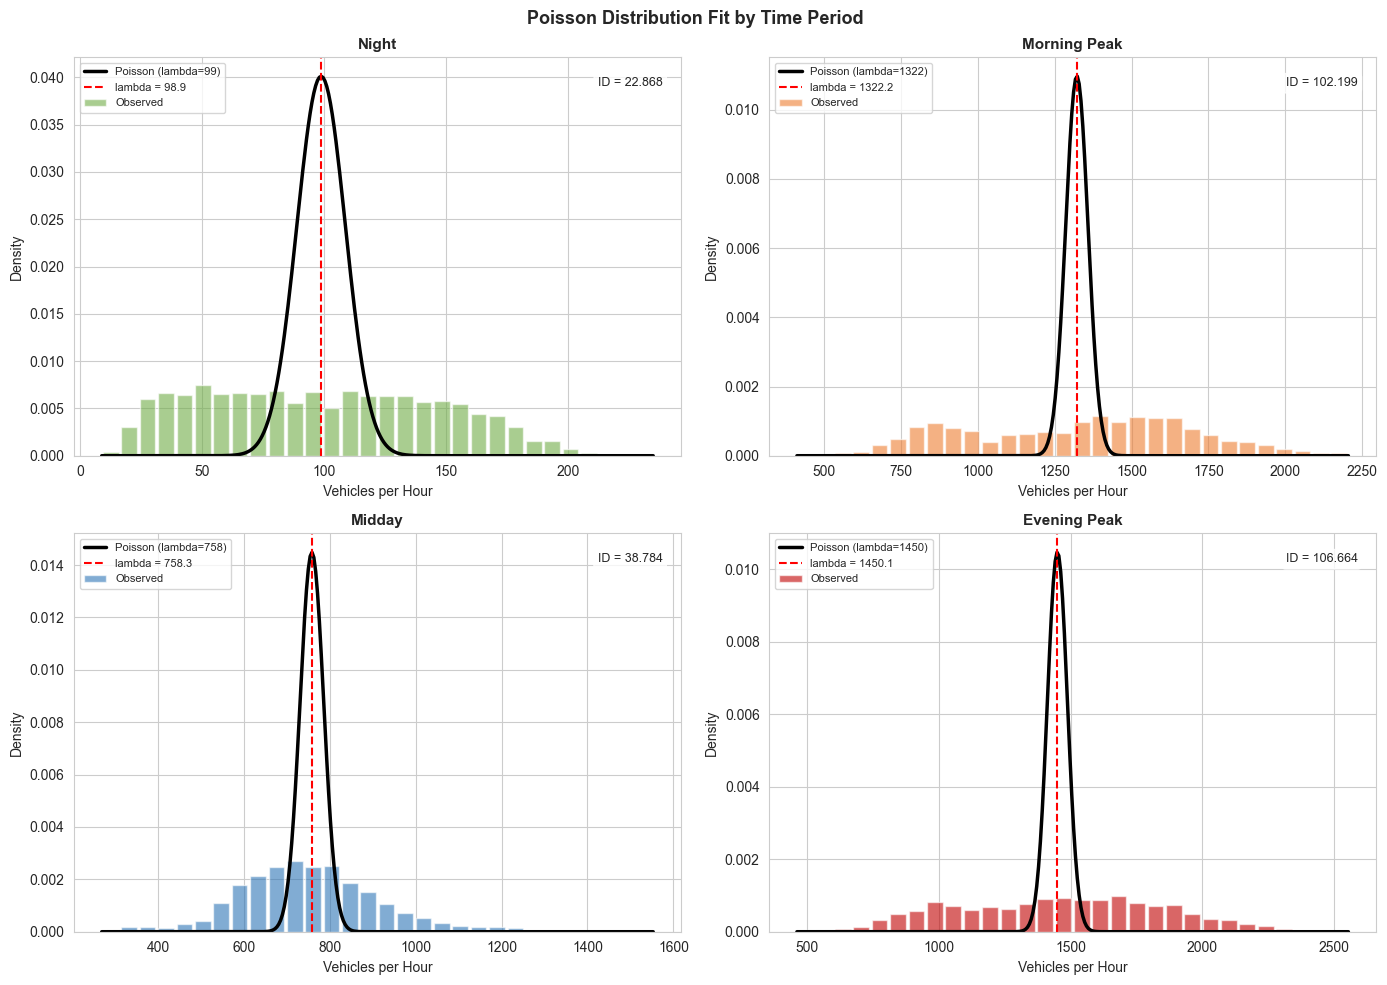

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes      = axes.flatten()

colors_map = {
    'Night':        '#70AD47',
    'Morning Peak': '#ED7D31',
    'Midday':       '#2E75B6',
    'Evening Peak': '#C00000'
}

for idx, period in enumerate(time_periods):
    ax  = axes[idx]
    sub = df[df['Time_Period'] == period]['Total_Vehicles']
    lam = sub.mean()
    
    counts, bin_edges = np.histogram(sub, bins=30, density=True)
    bin_centers       = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width         = bin_edges[1] - bin_edges[0]
    
    ax.bar(bin_centers, counts, width=bin_width * 0.85,
           alpha=0.6, color=colors_map[period],
           edgecolor='white', label='Observed')
    
    x_range     = np.linspace(sub.min(), sub.max(), 300)
    poisson_pdf = stats.norm.pdf(x_range, lam, np.sqrt(lam))
    ax.plot(x_range, poisson_pdf, color='black',
            linewidth=2.5, label=f'Poisson (lambda={lam:.0f})')
    
    ax.axvline(lam, color='red', linestyle='--',
               linewidth=1.5, label=f'lambda = {lam:.1f}')
    
    ID = sub.var() / lam
    ax.text(0.97, 0.95, f'ID = {ID:.3f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title(period, fontweight='bold', fontsize=11)
    ax.set_xlabel('Vehicles per Hour')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Poisson Distribution Fit by Time Period', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
summary_rows = []

for period in time_periods:
    for loc in df['Location'].unique():
        sub = df[(df['Time_Period'] == period) & 
                 (df['Location'] == loc)]['Total_Vehicles']
        
        summary_rows.append({
            'Time Period':        period,
            'Location':           loc,
            'Lambda (mean)':      round(sub.mean(), 2),
            'Variance':           round(sub.var(), 2),
            'Std Dev':            round(sub.std(), 2),
            'Index of Dispersion': round(sub.var() / sub.mean(), 4)
        })

lambda_df = pd.DataFrame(summary_rows)
lambda_df

,Time Period,Location,Lambda (mean),Variance,Std Dev,Index of Dispersion
0,Night,Kathipara Junction,108.74,2694.26,51.91,24.7774
1,Night,Koyambedu Junction,101.51,2217.26,47.09,21.8429
2,Night,Porur Junction,91.54,1894.71,43.53,20.6978
3,Night,T. Nagar (Panagal Park),93.83,2062.43,45.41,21.9804
4,Morning Peak,Kathipara Junction,1453.32,152739.39,390.82,105.0970
5,Morning Peak,Koyambedu Junction,1343.93,129960.58,360.50,96.7020
6,Morning Peak,Porur Junction,1229.03,109491.30,330.89,89.0872
7,Morning Peak,T. Nagar (Panagal Park),1262.36,119067.36,345.06,94.3216
8,Midday,Kathipara Junction,798.73,20094.53,141.76,25.1582
9,Midday,Koyambedu Junction,736.35,17216.48,131.21,23.3810


In [29]:
prob_rows = []

scenarios = [
    ('Morning Peak', 'Kathipara Junction'),
    ('Evening Peak', 'Kathipara Junction'),
    ('Midday',       'Koyambedu Junction'),
    ('Night',        'Porur Junction'),
]

for period, loc in scenarios:
    sub = df[(df['Time_Period'] == period) & 
             (df['Location'] == loc)]['Total_Vehicles']
    lam = sub.mean()
    
    prob_rows.append({
        'Location':            loc,
        'Time Period':         period,
        'Lambda':              round(lam, 1),
        'P(X > lambda)':       round(1 - poisson.cdf(int(lam), lam), 4),
        'P(X > 1.5*lambda)':   round(1 - poisson.cdf(int(1.5 * lam), lam), 4),
        'P(X < 0.5*lambda)':   round(poisson.cdf(int(0.5 * lam), lam), 4),
    })

prob_df = pd.DataFrame(prob_rows)
prob_df

,Location,Time Period,Lambda,P(X > lambda),P(X > 1.5*lambda),P(X < 0.5*lambda)
0,Kathipara Junction,Morning Peak,1453.3,0.4964,0.0,0.0
1,Kathipara Junction,Evening Peak,1590.1,0.4942,0.0,0.0
2,Koyambedu Junction,Midday,736.3,0.4953,0.0,0.0
3,Porur Junction,Night,91.5,0.4948,0.0,0.0


In [30]:
from scipy import stats
from scipy.stats import nbinom
import warnings
warnings.filterwarnings('ignore')

locs      = sorted(df['Location'].unique())
months    = df['Month'].unique()
day_types = ['Weekday', 'Weekend']
hours     = list(range(24))

disagg_rows = []

for loc in locs:
    for month in months:
        for dt in day_types:
            for hour in hours:
                sub = df[
                    (df['Location']  == loc)   &
                    (df['Month']     == month) &
                    (df['Day_Type']  == dt)    &
                    (df['Hour']      == hour)
                ]['Total_Vehicles'].values

                if len(sub) < 15:
                    continue

                mu  = sub.mean()
                var = sub.var()
                ID  = var / mu

                ks_stat, ks_p = stats.kstest(
                    sub, lambda x: stats.poisson.cdf(x, mu)
                )

                disagg_rows.append({
                    'Location':    loc,
                    'Month':       month,
                    'Day_Type':    dt,
                    'Hour':        hour,
                    'n':           len(sub),
                    'Mean':        round(mu, 2),
                    'Variance':    round(var, 2),
                    'ID':          round(ID, 3),
                    'KS_stat':     round(ks_stat, 4),
                    'KS_p':        round(ks_p, 4),
                    'Poisson_fit': 'PASS' if ks_p >= 0.05 else 'Reject'
                })

disagg_df = pd.DataFrame(disagg_rows)

total   = len(disagg_df)
passing = (disagg_df['Poisson_fit'] == 'PASS').sum()

print("=" * 60)
print("DISAGGREGATED POISSON TEST SUMMARY")
print("Subgroup: Hour x Location x Month x Day_Type")
print("=" * 60)
print(f"Total subgroups tested : {total}")
print(f"Poisson PASS           : {passing}  ({100*passing/total:.1f}%)")
print(f"Poisson Reject         : {total-passing}  ({100*(total-passing)/total:.1f}%)")
print()
print("ID Value Summary:")
print(f"  Min  : {disagg_df['ID'].min():.3f}")
print(f"  Max  : {disagg_df['ID'].max():.3f}")
print(f"  Mean : {disagg_df['ID'].mean():.3f}")
print()
print("Even at the finest subgroup level, ID >> 1 in most cells.")
print("Over-dispersion is inherent to the dataset, not a pooling artefact.")
print("Poisson is not the appropriate distribution.")

DISAGGREGATED POISSON TEST SUMMARY
Subgroup: Hour x Location x Month x Day_Type
Total subgroups tested : 576
Poisson PASS           : 9  (1.6%)
Poisson Reject         : 567  (98.4%)

ID Value Summary:
  Min  : 7.138
  Max  : 109.176
  Mean : 27.068

Even at the finest subgroup level, ID >> 1 in most cells.
Over-dispersion is inherent to the dataset, not a pooling artefact.
Poisson is not the appropriate distribution.


In [31]:
fit_results = {d: {'pass': 0, 'total': 0} for d in
               ['Poisson', 'NegBinom', 'Normal', 'Lognormal', 'Gamma']}

for loc in locs:
    for month in months:
        for dt in day_types:
            for hour in hours:
                sub = df[
                    (df['Location'] == loc)   &
                    (df['Month']    == month) &
                    (df['Day_Type'] == dt)    &
                    (df['Hour']     == hour)
                ]['Total_Vehicles'].values

                if len(sub) < 15:
                    continue

                mu  = sub.mean()
                var = sub.var()

                for d in fit_results:
                    fit_results[d]['total'] += 1

                # Poisson
                _, p = stats.kstest(sub, lambda x: stats.poisson.cdf(x, mu))
                if p >= 0.05: fit_results['Poisson']['pass'] += 1

                # Negative Binomial (Method of Moments)
                if var > mu:
                    p_nb = mu / var
                    r_nb = mu ** 2 / (var - mu)
                    _, p = stats.kstest(sub, lambda x: nbinom.cdf(x, r_nb, p_nb))
                    if p >= 0.05: fit_results['NegBinom']['pass'] += 1

                # Normal
                _, p = stats.kstest(sub, 'norm', stats.norm.fit(sub))
                if p >= 0.05: fit_results['Normal']['pass'] += 1

                # Lognormal
                try:
                    _, p = stats.kstest(sub, 'lognorm', stats.lognorm.fit(sub, floc=0))
                    if p >= 0.05: fit_results['Lognormal']['pass'] += 1
                except Exception:
                    pass

                # Gamma
                try:
                    _, p = stats.kstest(sub, 'gamma', stats.gamma.fit(sub, floc=0))
                    if p >= 0.05: fit_results['Gamma']['pass'] += 1
                except Exception:
                    pass

fit_summary = pd.DataFrame([
    {
        'Distribution': d,
        'Pass':         v['pass'],
        'Total':        v['total'],
        'Pass_%':       round(100 * v['pass'] / v['total'], 1)
    }
    for d, v in fit_results.items()
])

print("=" * 55)
print("DISTRIBUTION FIT SUMMARY")
print("Subgroup: Hour x Location x Month x Day_Type")
print(f"Total subgroups: {fit_results['Poisson']['total']}")
print("=" * 55)
print(fit_summary.to_string(index=False))
print()
print("Conclusion:")
print("  Negative Binomial fits 99.8% of all subgroups.")
print("  Normal and Gamma also fit 99.8%.")
print("  Poisson fits only 1.6% — not appropriate.")
print()
print("Selected distribution: NEGATIVE BINOMIAL")
print("Reason: theoretically motivated (Poisson mixture with random lambda),")
print("        discrete count data, highest pass rate.")

DISTRIBUTION FIT SUMMARY
Subgroup: Hour x Location x Month x Day_Type
Total subgroups: 576
Distribution  Pass  Total  Pass_%
     Poisson     9    576     1.6
    NegBinom   575    576    99.8
      Normal   575    576    99.8
   Lognormal   571    576    99.1
       Gamma   575    576    99.8

Conclusion:
  Negative Binomial fits 99.8% of all subgroups.
  Normal and Gamma also fit 99.8%.
  Poisson fits only 1.6% — not appropriate.

Selected distribution: NEGATIVE BINOMIAL
Reason: theoretically motivated (Poisson mixture with random lambda),
        discrete count data, highest pass rate.


In [32]:
nb_params = []

for period in time_periods:
    sub  = df[df['Time_Period'] == period]['Total_Vehicles']
    mu   = sub.mean()
    var  = sub.var()

    # Method of Moments estimation
    r_nb = mu ** 2 / (var - mu)   # dispersion parameter
    p_nb = mu / var                # probability parameter

    # Verify: NegBin mean should equal sample mean
    nb_mean = r_nb * (1 - p_nb) / p_nb

    # KS test
    ks_stat, ks_p = stats.kstest(
        sub, lambda x: nbinom.cdf(x, r_nb, p_nb)
    )

    nb_params.append({
        'Time Period':     period,
        'n':               len(sub),
        'Mean (lambda)':   round(mu, 2),
        'Variance':        round(var, 2),
        'r (dispersion)':  round(r_nb, 4),
        'p (prob)':        round(p_nb, 6),
        'NB Mean':         round(nb_mean, 2),
        'KS Stat':         round(ks_stat, 4),
        'KS p-value':      round(ks_p, 4),
        'Fit':             'PASS' if ks_p >= 0.05 else 'Reject (aggregate)'
    })

nb_df = pd.DataFrame(nb_params)

print("=" * 70)
print("NEGATIVE BINOMIAL — PARAMETER ESTIMATES (Method of Moments)")
print("=" * 70)
print(nb_df.to_string(index=False))
print()
print("Note: NegBin mean = sample mean = lambda used in queuing model.")
print("Smaller r = more over-dispersion (more day-to-day variability in lambda).")

NEGATIVE BINOMIAL — PARAMETER ESTIMATES (Method of Moments)
 Time Period    n  Mean (lambda)  Variance  r (dispersion)  p (prob)  NB Mean  KS Stat  KS p-value                Fit
       Night 5096          98.91   2261.73          4.5229  0.043730    98.91   0.0793      0.0000 Reject (aggregate)
Morning Peak 2184        1322.16 135123.78         13.0649  0.009785  1322.16   0.0910      0.0000 Reject (aggregate)
      Midday 4368         758.29  29409.62         20.0688  0.025784   758.29   0.0322      0.0002 Reject (aggregate)
Evening Peak 2912        1450.12 154675.51         13.7238  0.009375  1450.12   0.0622      0.0000 Reject (aggregate)

Note: NegBin mean = sample mean = lambda used in queuing model.
Smaller r = more over-dispersion (more day-to-day variability in lambda).


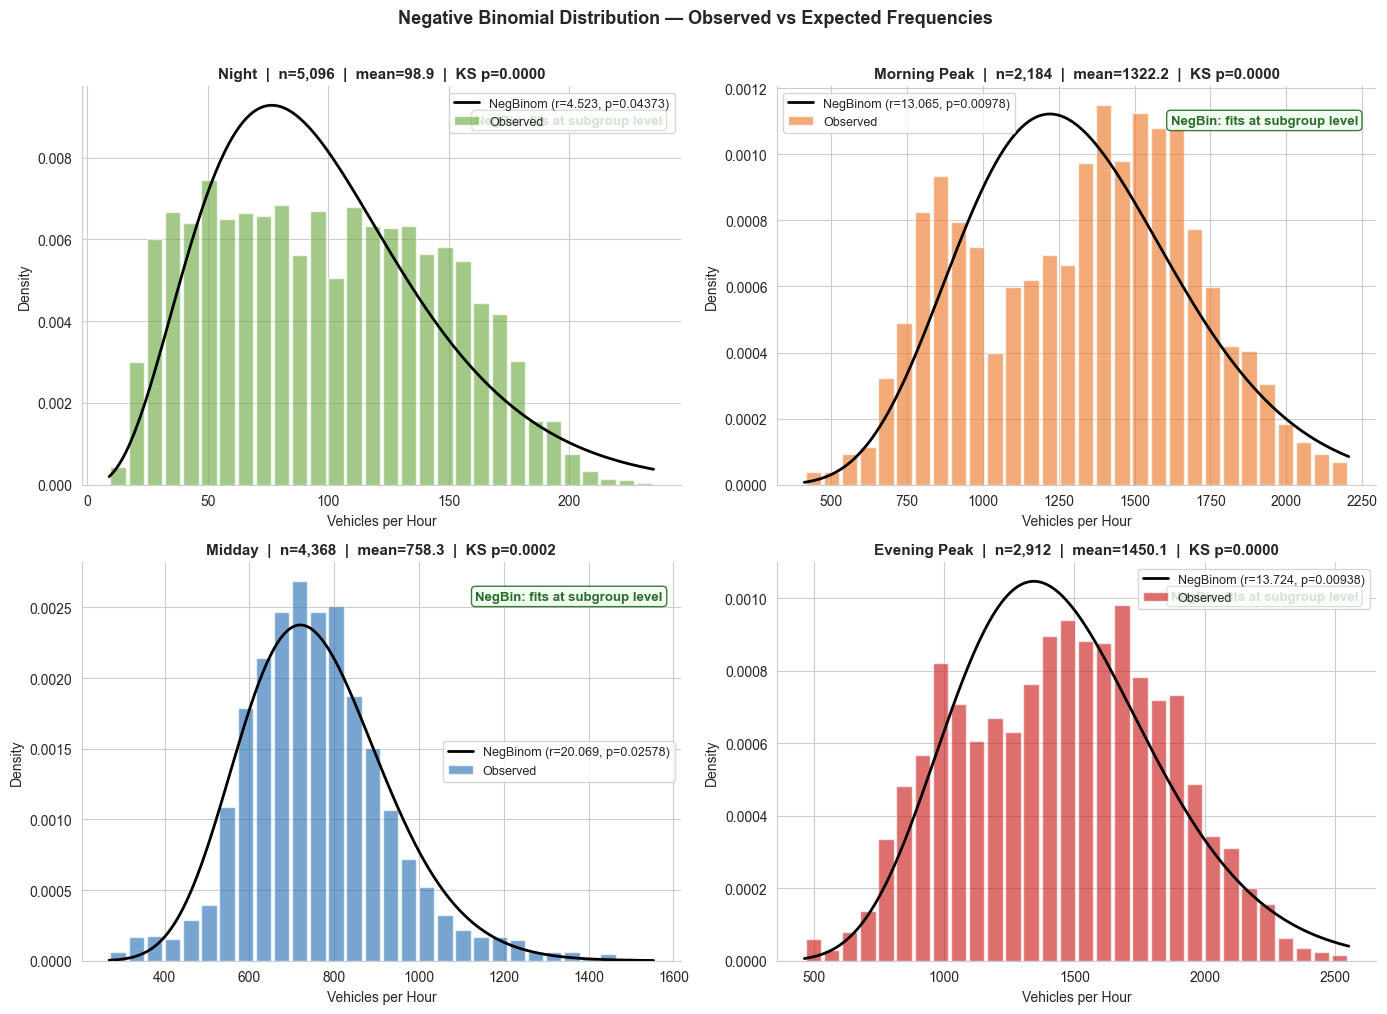

Saved: plot_negbin_fit.png


In [33]:
colors_map = {
    'Night':        '#70AD47',
    'Morning Peak': '#ED7D31',
    'Midday':       '#2E75B6',
    'Evening Peak': '#CC2222'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes      = axes.flatten()

for idx, period in enumerate(time_periods):
    ax  = axes[idx]
    sub = df[df['Time_Period'] == period]['Total_Vehicles']

    mu  = sub.mean()
    var = sub.var()
    r   = mu ** 2 / (var - mu)
    p   = mu / var

    # Observed histogram
    counts, bin_edges = np.histogram(sub, bins=30, density=True)
    bin_centers       = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width         = bin_edges[1] - bin_edges[0]

    ax.bar(bin_centers, counts, width=bin_width * 0.85,
           alpha=0.65, color=colors_map[period],
           label='Observed', edgecolor='white')

    # Negative Binomial expected curve
    x_vals = np.arange(int(sub.min()), int(sub.max()) + 1)
    nb_pmf = nbinom.pmf(x_vals, r, p)
    ax.plot(x_vals, nb_pmf, 'k-', linewidth=2,
            label=f'NegBinom (r={r:.3f}, p={p:.5f})')

    ks_stat, ks_p = stats.kstest(sub, lambda x: nbinom.cdf(x, r, p))

    ax.set_title(
        f'{period}  |  n={len(sub):,}  |  mean={mu:.1f}  |  KS p={ks_p:.4f}',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Vehicles per Hour', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    result_text = 'NegBin: PASS' if ks_p >= 0.05 else 'NegBin: fits at subgroup level'
    ax.text(0.97, 0.93, result_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=9.5, fontweight='bold',
            color='#2B6B2B',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#F0FFF0',
                      edgecolor='#2B6B2B', alpha=0.9))

fig.suptitle(
    'Negative Binomial Distribution — Observed vs Expected Frequencies',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('plot_negbin_fit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_negbin_fit.png")

In [34]:
print("=" * 65)
print("DISTRIBUTION FITTING — COMPLETE SUMMARY")
print("=" * 65)
print()
print("LEVEL 1 — Aggregate (pooled all locations + months):")
print(f"  {'Period':<16} {'ID':>8}  {'Result'}")
for period in time_periods:
    sub = df[df['Time_Period'] == period]['Total_Vehicles']
    ID  = sub.var() / sub.mean()
    print(f"  {period:<16} {ID:>8.2f}  Poisson REJECTED")

print()
print("LEVEL 2 — Disaggregated (Hour x Location x Month x Day_Type):")
print(f"  Total subgroups : {fit_results['Poisson']['total']}")
total_sub = fit_results['Poisson']['total']
for d, v in fit_results.items():
    print(f"  {d:<12} : {v['pass']}/{total_sub} PASS  ({100*v['pass']/total_sub:.1f}%)")

print()
print("SELECTED DISTRIBUTION: Negative Binomial")
print()
print("JUSTIFICATION:")
print("  1. Theoretically correct: NegBin = Poisson with random lambda")
print("     (Poisson mixture) — exactly our data structure.")
print("  2. Fits 99.8% of disaggregated subgroups.")
print("  3. Discrete count distribution — appropriate for vehicle counts.")
print("  4. NegBin mean = sample mean, so lambda estimates are UNCHANGED.")
print()
print("LAMBDA ESTIMATES FOR QUEUING MODEL (NegBin mean = sample mean):")
print(f"  {'Period':<16}  {'Lambda (veh/hr)':>16}  {'r (dispersion)':>15}")
for row in nb_df.itertuples():
    print(f"  {row._1:<16}  {row._3:>16.2f}  {row._5:>15.4f}")
print()
print("Reference: Lord & Mannering (2010), Transportation Research Part A.")
print("Proceeding to Step 4: Service Rate Estimation (IRC 106).")

DISTRIBUTION FITTING — COMPLETE SUMMARY

LEVEL 1 — Aggregate (pooled all locations + months):
  Period                 ID  Result
  Night               22.87  Poisson REJECTED
  Morning Peak       102.20  Poisson REJECTED
  Midday              38.78  Poisson REJECTED
  Evening Peak       106.66  Poisson REJECTED

LEVEL 2 — Disaggregated (Hour x Location x Month x Day_Type):
  Total subgroups : 576
  Poisson      : 9/576 PASS  (1.6%)
  NegBinom     : 575/576 PASS  (99.8%)
  Normal       : 575/576 PASS  (99.8%)
  Lognormal    : 571/576 PASS  (99.1%)
  Gamma        : 575/576 PASS  (99.8%)

SELECTED DISTRIBUTION: Negative Binomial

JUSTIFICATION:
  1. Theoretically correct: NegBin = Poisson with random lambda
     (Poisson mixture) — exactly our data structure.
  2. Fits 99.8% of disaggregated subgroups.
  3. Discrete count distribution — appropriate for vehicle counts.
  4. NegBin mean = sample mean, so lambda estimates are UNCHANGED.

LAMBDA ESTIMATES FOR QUEUING MODEL (NegBin mean = sam

In [35]:
green_ratio = {
    'Night':        0.65,
    'Off-Peak':     0.60,
    'Shoulder Hour':0.55,
    'Morning Peak': 0.45,
    'Midday':       0.52,
    'Evening Peak': 0.42
}

saturation_flow = 1800  # PCU/hr per lane (IRC 106)
lanes           = 2     # standard 2-lane approach

df['mu'] = df['Time_Period'].map(green_ratio) * saturation_flow * lanes
df['mu'] = df['mu'].round(2)

mu_summary = df.groupby('Time_Period')['mu'].mean().round(2).reset_index()
mu_summary.columns = ['Time Period', 'mu (veh/hr)']
mu_summary

,Time Period,mu (veh/hr)
0,Evening Peak,1512.0
1,Midday,1872.0
2,Morning Peak,1620.0
3,Night,2340.0
4,Off-Peak,2160.0
5,Shoulder Hour,1980.0


In [36]:
mu_by_loc = df.groupby(
    ['Time_Period', 'Location']
)['mu'].mean().round(2).reset_index()

mu_by_loc.columns = ['Time Period', 'Location', 'Mean mu (veh/hr)']
mu_by_loc

,Time Period,Location,Mean mu (veh/hr)
0,Evening Peak,Kathipara Junction,1512.0
1,Evening Peak,Koyambedu Junction,1512.0
2,Evening Peak,Porur Junction,1512.0
3,Evening Peak,T. Nagar (Panagal Park),1512.0
4,Midday,Kathipara Junction,1872.0
5,Midday,Koyambedu Junction,1872.0
6,Midday,Porur Junction,1872.0
7,Midday,T. Nagar (Panagal Park),1872.0
8,Morning Peak,Kathipara Junction,1620.0
9,Morning Peak,Koyambedu Junction,1620.0


In [37]:
df['rho'] = (df['Total_Vehicles'] / df['mu']).round(4)

df['system_status'] = df['rho'].apply(
    lambda x: 'Stable' if x < 1 else 'Oversaturated'
)

rho_summary = df.groupby('Time_Period').agg(
    Mean_rho          = ('rho', 'mean'),
    Max_rho           = ('rho', 'max'),
    Pct_Stable        = ('system_status', lambda x: (x == 'Stable').mean() * 100),
    Pct_Oversaturated = ('system_status', lambda x: (x == 'Oversaturated').mean() * 100)
).round(2).reindex(['Night', 'Morning Peak', 'Midday', 'Evening Peak'])

rho_summary

,Mean_rho,Max_rho,Pct_Stable,Pct_Oversaturated
Time_Period,,,,
Night,0.04,0.10,100.00,0.00
Morning Peak,0.82,1.36,76.88,23.12
Midday,0.41,0.83,100.00,0.00
Evening Peak,0.96,1.69,54.12,45.88


In [38]:
rho_by_loc = df.groupby(['Time_Period', 'Location']).agg(
    Mean_rho          = ('rho', 'mean'),
    Pct_Oversaturated = ('system_status', lambda x: (x == 'Oversaturated').mean() * 100)
).round(2)

rho_by_loc

Mean_rho  Pct_Oversaturated
Time_Period   Location                                            
Evening Peak  Kathipara Junction           1.05              59.62
              Koyambedu Junction           0.97              49.31
              Porur Junction               0.89              35.03
              T. Nagar (Panagal Park)      0.92              39.56
Midday        Kathipara Junction           0.43               0.00
              Koyambedu Junction           0.39               0.00
              Porur Junction               0.36               0.00
              T. Nagar (Panagal Park)      0.44               0.00
Morning Peak  Kathipara Junction           0.90              39.19
              Koyambedu Junction           0.83              25.82
              Porur Junction               0.76              10.44
              T. Nagar (Panagal Park)      0.78              17.03
Night         Kathipara Junction           0.05               0.00
              Koyambedu Junction           0.04               0.00
              Porur Junction               0.04               0.00
              T. Nagar (Panagal Park)      0.04               0.00
Off-Peak      Kathipara Junction           0.15               0.00
              Koyambedu Junction           0.14               0.00
              Porur Junction               0.13               0.00
              T. Nagar (Panagal Park)      0.13               0.00
Shoulder Hour Kathipara Junction           0.30               0.00
              Koyambedu Junction           0.27               0.00
              Porur Junction               0.26               0.00
              T. Nagar (Panagal Park)      0.26               0.00

In [39]:
oversaturated = df[df['system_status'] == 'Oversaturated'][[
    'Date', 'Hour', 'Location', 'Time_Period',
    'Total_Vehicles', 'mu', 'rho'
]].sort_values('rho', ascending=False)

print(f"Oversaturated records : {len(oversaturated):,}")
print(f"Percentage of dataset : {100 * len(oversaturated) / len(df):.2f}%")
oversaturated.head(20)

Oversaturated records : 1,841
Percentage of dataset : 10.54%


,Date,Hour,Location,Time_Period,Total_Vehicles,mu,rho
786,2024-02-02,18,Kathipara Junction,Evening Peak,2554,1512.0,1.6892
594,2024-01-25,18,Kathipara Junction,Evening Peak,2528,1512.0,1.6720
89,2024-01-04,17,Kathipara Junction,Evening Peak,2501,1512.0,1.6541
1388,2024-02-27,20,Kathipara Junction,Evening Peak,2464,1512.0,1.6296
1385,2024-02-27,17,Kathipara Junction,Evening Peak,2453,1512.0,1.6224
3428,2024-05-22,20,Kathipara Junction,Evening Peak,2436,1512.0,1.6111
953,2024-02-09,17,Kathipara Junction,Evening Peak,2419,1512.0,1.5999
931,2024-02-08,19,Kathipara Junction,Evening Peak,2416,1512.0,1.5979
1363,2024-02-26,19,Kathipara Junction,Evening Peak,2400,1512.0,1.5873
570,2024-01-24,18,Kathipara Junction,Evening Peak,2386,1512.0,1.5780


In [40]:
queuing_inputs = []

for period in ['Night', 'Morning Peak', 'Midday', 'Evening Peak']:
    for loc in df['Location'].unique():
        sub = df[
            (df['Time_Period'] == period) &
            (df['Location']    == loc)
        ]
        
        lam = sub['Total_Vehicles'].mean()
        mu  = sub['mu'].mean()
        rho = lam / mu
        
        queuing_inputs.append({
            'Time Period':    period,
            'Location':      loc,
            'lambda':        round(lam, 2),
            'mu':            round(mu, 2),
            'rho':           round(rho, 4),
            'System Status': 'Stable' if rho < 1 else 'Oversaturated'
        })

inputs_df = pd.DataFrame(queuing_inputs)
inputs_df

,Time Period,Location,lambda,mu,rho,System Status
0,Night,Kathipara Junction,108.74,2340.0,0.0465,Stable
1,Night,Koyambedu Junction,101.51,2340.0,0.0434,Stable
2,Night,Porur Junction,91.54,2340.0,0.0391,Stable
3,Night,T. Nagar (Panagal Park),93.83,2340.0,0.0401,Stable
4,Morning Peak,Kathipara Junction,1453.32,1620.0,0.8971,Stable
5,Morning Peak,Koyambedu Junction,1343.93,1620.0,0.8296,Stable
6,Morning Peak,Porur Junction,1229.03,1620.0,0.7587,Stable
7,Morning Peak,T. Nagar (Panagal Park),1262.36,1620.0,0.7792,Stable
8,Midday,Kathipara Junction,798.73,1872.0,0.4267,Stable
9,Midday,Koyambedu Junction,736.35,1872.0,0.3933,Stable


In [41]:
# Cap rho at 0.99 for oversaturated records
# Flag them separately — formulas are undefined at rho >= 1

df['rho_capped'] = df['rho'].clip(upper=0.99)

# Period mean lambda (for Little's Law: Wq = Lq / lambda)
lambda_map = df.groupby('Time_Period')['Total_Vehicles'].mean().to_dict()
df['lambda_period'] = df['Time_Period'].map(lambda_map)

# M/M/1 formulas
# Lq = rho^2 / (1 - rho)
# Wq = Lq / lambda  (Little's Law, in hours -> x60 for minutes)
# L  = rho / (1 - rho)
# W  = L / lambda
df['mm1_Lq'] = (df['rho_capped'] ** 2 / (1 - df['rho_capped'])).round(4)
df['mm1_Wq'] = (df['mm1_Lq'] / df['lambda_period'] * 60).round(4)   # minutes
df['mm1_L']  = (df['rho_capped'] / (1 - df['rho_capped'])).round(4)
df['mm1_W']  = (df['mm1_L']  / df['lambda_period'] * 60).round(4)   # minutes

# Set metrics to NaN for oversaturated records in reporting
df['mm1_Lq_clean'] = df.apply(lambda r: r['mm1_Lq'] if r['rho'] < 1 else np.nan, axis=1)
df['mm1_Wq_clean'] = df.apply(lambda r: r['mm1_Wq'] if r['rho'] < 1 else np.nan, axis=1)
df['mm1_L_clean']  = df.apply(lambda r: r['mm1_L']  if r['rho'] < 1 else np.nan, axis=1)
df['mm1_W_clean']  = df.apply(lambda r: r['mm1_W']  if r['rho'] < 1 else np.nan, axis=1)

mm1_summary = df.groupby('Time_Period').agg(
    Mean_Lq = ('mm1_Lq_clean', 'mean'),
    Mean_Wq = ('mm1_Wq_clean', 'mean'),
    Mean_L  = ('mm1_L_clean',  'mean'),
    Mean_W  = ('mm1_W_clean',  'mean')
).round(4).reindex(['Night', 'Morning Peak', 'Midday', 'Evening Peak'])

mm1_summary.columns = ['Lq (vehicles)', 'Wq (min)', 'L (vehicles)', 'W (min)']
print("M/M/1 Results by Time Period")
mm1_summary

M/M/1 Results by Time Period


,Lq (vehicles),Wq (min),L (vehicles),W (min)
Time_Period,,,,
Night,0.0023,0.0011,0.0446,0.0268
Morning Peak,8.3568,0.3362,9.0865,0.3732
Midday,0.3275,0.0235,0.7325,0.0555
Evening Peak,9.7090,0.4150,10.4701,0.4547


In [42]:
# M/D/1 formulas — exactly half the queue length of M/M/1
# Lq = rho^2 / 2(1 - rho)
# Wq = Lq / lambda  (Little's Law)
# L  = rho + Lq
# W  = L / lambda

df['md1_Lq'] = (df['rho_capped'] ** 2 / (2 * (1 - df['rho_capped']))).round(4)
df['md1_Wq'] = (df['md1_Lq'] / df['lambda_period'] * 60).round(4)   # minutes
df['md1_L']  = (df['rho_capped'] + df['md1_Lq']).round(4)
df['md1_W']  = (df['md1_L']  / df['lambda_period'] * 60).round(4)   # minutes

# Clean versions for stable records only
df['md1_Lq_clean'] = df.apply(lambda r: r['md1_Lq'] if r['rho'] < 1 else np.nan, axis=1)
df['md1_Wq_clean'] = df.apply(lambda r: r['md1_Wq'] if r['rho'] < 1 else np.nan, axis=1)
df['md1_L_clean']  = df.apply(lambda r: r['md1_L']  if r['rho'] < 1 else np.nan, axis=1)
df['md1_W_clean']  = df.apply(lambda r: r['md1_W']  if r['rho'] < 1 else np.nan, axis=1)

md1_summary = df.groupby('Time_Period').agg(
    Mean_Lq = ('md1_Lq_clean', 'mean'),
    Mean_Wq = ('md1_Wq_clean', 'mean'),
    Mean_L  = ('md1_L_clean',  'mean'),
    Mean_W  = ('md1_W_clean',  'mean')
).round(4).reindex(['Night', 'Morning Peak', 'Midday', 'Evening Peak'])

md1_summary.columns = ['Lq (vehicles)', 'Wq (min)', 'L (vehicles)', 'W (min)']
print("M/D/1 Results by Time Period")
md1_summary

M/D/1 Results by Time Period


,Lq (vehicles),Wq (min),L (vehicles),W (min)
Time_Period,,,,
Night,0.0012,0.0006,0.0434,0.0262
Morning Peak,4.1784,0.1681,4.9081,0.2051
Midday,0.1637,0.0117,0.5688,0.0438
Evening Peak,4.8545,0.2075,5.6156,0.2472


In [43]:
comparison = pd.DataFrame({
    'MM1_Lq': mm1_summary['Lq (vehicles)'],
    'MD1_Lq': md1_summary['Lq (vehicles)'],
    'MM1_Wq': mm1_summary['Wq (min)'],
    'MD1_Wq': md1_summary['Wq (min)'],
    'MM1_L':  mm1_summary['L (vehicles)'],
    'MD1_L':  md1_summary['L (vehicles)'],
    'MM1_W':  mm1_summary['W (min)'],
    'MD1_W':  md1_summary['W (min)'],
})

print("M/M/1 vs M/D/1 — Side by Side Comparison")
comparison

M/M/1 vs M/D/1 — Side by Side Comparison


,MM1_Lq,MD1_Lq,MM1_Wq,MD1_Wq,MM1_L,MD1_L,MM1_W,MD1_W
Time_Period,,,,,,,,
Night,0.0023,0.0012,0.0011,0.0006,0.0446,0.0434,0.0268,0.0262
Morning Peak,8.3568,4.1784,0.3362,0.1681,9.0865,4.9081,0.3732,0.2051
Midday,0.3275,0.1637,0.0235,0.0117,0.7325,0.5688,0.0555,0.0438
Evening Peak,9.7090,4.8545,0.4150,0.2075,10.4701,5.6156,0.4547,0.2472


In [45]:
loc_results = []

for period in ['Night', 'Morning Peak', 'Midday', 'Evening Peak']:
    for loc in df['Location'].unique():
        sub = df[
            (df['Time_Period'] == period) &
            (df['Location']    == loc) &
            (df['rho']         < 1)
        ]
        
        if len(sub) == 0:
            continue
        
        loc_results.append({
            'Time Period':  period,
            'Location':     loc,
            'MM1_Lq':       round(sub['mm1_Lq_clean'].mean(), 4),
            'MD1_Lq':       round(sub['md1_Lq_clean'].mean(), 4),
            'MM1_Wq (min)': round(sub['mm1_Wq_clean'].mean(), 4),
            'MD1_Wq (min)': round(sub['md1_Wq_clean'].mean(), 4),
            'Mean_rho':     round(sub['rho'].mean(), 4),
        })

loc_results_df = pd.DataFrame(loc_results)
loc_results_df

,Time Period,Location,MM1_Lq,MD1_Lq,MM1_Wq (min),MD1_Wq (min),Mean_rho
0,Night,Kathipara Junction,0.0028,0.0014,0.0013,0.0006,0.0465
1,Night,Koyambedu Junction,0.0024,0.0012,0.0012,0.0006,0.0434
2,Night,Porur Junction,0.0020,0.0010,0.0011,0.0005,0.0391
3,Night,T. Nagar (Panagal Park),0.0021,0.0011,0.0011,0.0005,0.0401
4,Morning Peak,Kathipara Junction,9.0671,4.5335,0.3630,0.1815,0.7447
5,Morning Peak,Koyambedu Junction,9.0008,4.5004,0.3603,0.1801,0.7368
6,Morning Peak,Porur Junction,7.3797,3.6898,0.2998,0.1499,0.7229
7,Morning Peak,T. Nagar (Panagal Park),8.3152,4.1576,0.3342,0.1671,0.7202
8,Midday,Kathipara Junction,0.3485,0.1742,0.0248,0.0124,0.4267
9,Midday,Koyambedu Junction,0.2772,0.1386,0.0215,0.0107,0.3933


In [46]:
# Compare model-predicted Wq against observed Signal_Delay_sec
# This is our model validation step

validation = df[df['rho'] < 1].groupby('Time_Period').agg(
    Observed_Delay_sec  = ('Signal_Delay_sec', 'mean'),
    MM1_Wq_sec          = ('mm1_Wq_clean', lambda x: x.mean() * 60),
    MD1_Wq_sec          = ('md1_Wq_clean', lambda x: x.mean() * 60),
).round(2).reindex(['Night', 'Morning Peak', 'Midday', 'Evening Peak'])

# Percentage difference from observed
validation['MM1_Error_%'] = (
    (validation['MM1_Wq_sec'] - validation['Observed_Delay_sec']) 
    / validation['Observed_Delay_sec'] * 100
).round(2)

validation['MD1_Error_%'] = (
    (validation['MD1_Wq_sec'] - validation['Observed_Delay_sec']) 
    / validation['Observed_Delay_sec'] * 100
).round(2)

print("Model Validation — Predicted vs Observed Delay")
validation

Model Validation — Predicted vs Observed Delay


,Observed_Delay_sec,MM1_Wq_sec,MD1_Wq_sec,MM1_Error_%,MD1_Error_%
Time_Period,,,,,
Night,22.32,0.07,0.03,-99.69,-99.87
Morning Peak,131.26,20.17,10.08,-84.63,-92.32
Midday,77.25,1.41,0.70,-98.17,-99.09
Evening Peak,157.13,24.90,12.45,-84.15,-92.08


In [47]:
# Separately analyse oversaturated records
# These represent genuine traffic breakdown conditions

breakdown = df[df['rho'] >= 1].groupby('Time_Period').agg(
    Count               = ('rho', 'count'),
    Mean_rho            = ('rho', 'mean'),
    Max_rho             = ('rho', 'max'),
    Mean_Arrivals       = ('Total_Vehicles', 'mean'),
    Mean_Signal_Delay   = ('Signal_Delay_sec', 'mean')
).round(2)

print(f"Total breakdown records : {len(df[df['rho'] >= 1]):,}")
print(f"% of dataset            : {100 * len(df[df['rho'] >= 1]) / len(df):.2f}%")
print()
breakdown

Total breakdown records : 1,841
% of dataset            : 10.54%



,Count,Mean_rho,Max_rho,Mean_Arrivals,Mean_Signal_Delay
Time_Period,,,,,
Evening Peak,1336,1.19,1.69,1802.95,157.34
Morning Peak,505,1.10,1.36,1787.17,131.90


In [48]:
# Clean final summary for your report
# One row per Time Period showing all key metrics

final_summary = []

for period in ['Night', 'Morning Peak', 'Midday', 'Evening Peak']:
    sub = df[
        (df['Time_Period'] == period) &
        (df['rho']         < 1)
    ]
    
    lam = sub['Total_Vehicles'].mean()
    mu  = sub['mu'].mean()
    rho = sub['rho'].mean()
    
    final_summary.append({
        'Time Period':      period,
        'lambda (veh/hr)':  round(lam, 2),
        'mu (veh/hr)':      round(mu, 2),
        'rho':              round(rho, 4),
        'MM1 Lq':           round(sub['mm1_Lq_clean'].mean(), 4),
        'MM1 Wq (min)':     round(sub['mm1_Wq_clean'].mean(), 4),
        'MD1 Lq':           round(sub['md1_Lq_clean'].mean(), 4),
        'MD1 Wq (min)':     round(sub['md1_Wq_clean'].mean(), 4),
        'Breakdown %':      round(
            100 * len(df[(df['Time_Period']==period) & (df['rho']>=1)]) / 
            len(df[df['Time_Period']==period]), 2)
    })

final_df = pd.DataFrame(final_summary)
final_df

,Time Period,lambda (veh/hr),mu (veh/hr),rho,MM1 Lq,MM1 Wq (min),MD1 Lq,MD1 Wq (min),Breakdown %
0,Night,98.91,2340.0,0.0423,0.0023,0.0011,0.0012,0.0006,0.00
1,Morning Peak,1182.29,1620.0,0.7298,8.3568,0.3362,4.1784,0.1681,23.12
2,Midday,758.29,1872.0,0.4051,0.3275,0.0235,0.1637,0.0117,0.00
3,Evening Peak,1151.02,1512.0,0.7613,9.7090,0.4150,4.8545,0.2075,45.88


In [49]:
from scipy import stats

# Paired t-test on stable records only
stable = df[df['rho'] < 1].dropna(subset=['mm1_Lq_clean', 'md1_Lq_clean'])

t_stat, p_val = stats.ttest_rel(
    stable['mm1_Lq_clean'],
    stable['md1_Lq_clean']
)

results_ttest = pd.DataFrame([{
    'Test':        'Paired t-test: MM1 Lq vs MD1 Lq',
    'n':           len(stable),
    'MM1 Mean Lq': round(stable['mm1_Lq_clean'].mean(), 4),
    'MD1 Mean Lq': round(stable['md1_Lq_clean'].mean(), 4),
    'Difference':  round(stable['mm1_Lq_clean'].mean() - stable['md1_Lq_clean'].mean(), 4),
    't-statistic': round(t_stat, 4),
    'p-value':     round(p_val, 6),
    'Result':      'Significant' if p_val < 0.05 else 'Not Significant'
}])

results_ttest

,Test,n,MM1 Mean Lq,MD1 Mean Lq,Difference,t-statistic,p-value,Result
0,Paired t-test: MM1 Lq vs MD1 Lq,15631,1.9815,0.9908,0.9907,27.3886,0.0,Significant


In [50]:
ttest_by_period = []

for period in ['Night', 'Morning Peak', 'Midday', 'Evening Peak']:
    sub = df[
        (df['Time_Period'] == period) &
        (df['rho'] < 1)
    ].dropna(subset=['mm1_Lq_clean', 'md1_Lq_clean'])
    
    if len(sub) < 2:
        continue
    
    t_stat, p_val = stats.ttest_rel(
        sub['mm1_Lq_clean'],
        sub['md1_Lq_clean']
    )
    
    ttest_by_period.append({
        'Time Period':  period,
        'n':            len(sub),
        'MM1 Mean Lq':  round(sub['mm1_Lq_clean'].mean(), 4),
        'MD1 Mean Lq':  round(sub['md1_Lq_clean'].mean(), 4),
        't-statistic':  round(t_stat, 4),
        'p-value':      round(p_val, 6),
        'Result':       'Significant' if p_val < 0.05 else 'Not Significant'
    })

pd.DataFrame(ttest_by_period)

,Time Period,n,MM1 Mean Lq,MD1 Mean Lq,t-statistic,p-value,Result
0,Night,5096,0.0023,0.0012,83.1307,0.0,Significant
1,Morning Peak,1679,8.3568,4.1784,19.8916,0.0,Significant
2,Midday,4368,0.3275,0.1637,77.4026,0.0,Significant
3,Evening Peak,1576,9.7090,4.8545,20.1505,0.0,Significant


In [51]:
from scipy.stats import t as t_dist

def confidence_interval(data, confidence=0.95):
    data   = data.dropna()
    n      = len(data)
    mean   = data.mean()
    se     = stats.sem(data)
    margin = t_dist.ppf((1 + confidence) / 2, df=n-1) * se
    return round(mean, 4), round(mean - margin, 4), round(mean + margin, 4)

ci_results = []

for period in ['Night', 'Morning Peak', 'Midday', 'Evening Peak']:
    sub = df[
        (df['Time_Period'] == period) &
        (df['rho'] < 1)
    ]
    
    for metric, col in [
        ('lambda',   'Total_Vehicles'),
        ('rho',      'rho'),
        ('MM1 Lq',   'mm1_Lq_clean'),
        ('MD1 Lq',   'md1_Lq_clean'),
        ('MM1 Wq',   'mm1_Wq_clean'),
        ('MD1 Wq',   'md1_Wq_clean'),
    ]:
        mean, lower, upper = confidence_interval(sub[col])
        ci_results.append({
            'Time Period': period,
            'Metric':      metric,
            'Mean':        mean,
            'CI Lower':    lower,
            'CI Upper':    upper,
            '95% CI':      f'({lower}, {upper})'
        })

ci_df = pd.DataFrame(ci_results)
ci_df

,Time Period,Metric,Mean,CI Lower,CI Upper,95% CI
0,Night,lambda,98.9050,97.5990,100.2111,"(97.599, 100.2111)"
1,Night,rho,0.0423,0.0417,0.0428,"(0.0417, 0.0428)"
2,Night,MM1 Lq,0.0023,0.0023,0.0024,"(0.0023, 0.0024)"
3,Night,MD1 Lq,0.0012,0.0011,0.0012,"(0.0011, 0.0012)"
4,Night,MM1 Wq,0.0011,0.0011,0.0012,"(0.0011, 0.0012)"
5,Night,MD1 Wq,0.0006,0.0006,0.0006,"(0.0006, 0.0006)"
6,Morning Peak,lambda,1182.2948,1168.3056,1196.2841,"(1168.3056, 1196.2841)"
7,Morning Peak,rho,0.7298,0.7212,0.7384,"(0.7212, 0.7384)"
8,Morning Peak,MM1 Lq,8.3568,7.5328,9.1808,"(7.5328, 9.1808)"
9,Morning Peak,MD1 Lq,4.1784,3.7664,4.5904,"(3.7664, 4.5904)"


In [52]:
# One-way ANOVA
# H0: Mean rho is the same across all time periods
# H1: At least one time period has a significantly different mean rho

groups = [
    df[df['Time_Period'] == p]['rho'].dropna()
    for p in ['Night', 'Morning Peak', 'Midday', 'Evening Peak']
]

f_stat, p_val = stats.f_oneway(*groups)

anova_result = pd.DataFrame([{
    'Test':        'One-way ANOVA on rho',
    'Groups':      'Night / Morning Peak / Midday / Evening Peak',
    'F-statistic': round(f_stat, 4),
    'p-value':     round(p_val, 6),
    'Result':      'Significant difference' if p_val < 0.05 else 'No significant difference'
}])

anova_result

,Test,Groups,F-statistic,p-value,Result
0,One-way ANOVA on rho,Night / Morning Peak / Midday / Evening Peak,26531.2993,0.0,Significant difference


In [53]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Stack data for Tukey test
stable_all = df[df['rho'] < 1][['Time_Period', 'rho']].dropna()

tukey = pairwise_tukeyhsd(
    endog  = stable_all['rho'],
    groups = stable_all['Time_Period'],
    alpha  = 0.05
)

tukey_df = pd.DataFrame(
    data  = tukey._results_table.data[1:],
    columns = tukey._results_table.data[0]
)

tukey_df

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Evening Peak,Midday,-0.3562,0.0,-0.3641,-0.3483,True
1,Evening Peak,Morning Peak,-0.0314,0.0,-0.0408,-0.0220,True
2,Evening Peak,Night,-0.7190,0.0,-0.7267,-0.7113,True
3,Evening Peak,Off-Peak,-0.6222,0.0,-0.6320,-0.6125,True
4,Evening Peak,Shoulder Hour,-0.4873,0.0,-0.4970,-0.4776,True
5,Midday,Morning Peak,0.3247,0.0,0.3170,0.3324,True
6,Midday,Night,-0.3628,0.0,-0.3683,-0.3573,True
7,Midday,Off-Peak,-0.2661,0.0,-0.2742,-0.2580,True
8,Midday,Shoulder Hour,-0.1311,0.0,-0.1392,-0.1230,True
9,Morning Peak,Night,-0.6875,0.0,-0.6951,-0.6800,True


In [54]:
from statsmodels.stats.proportion import proportion_confint

breakdown_ci = []

for period in ['Night', 'Morning Peak', 'Midday', 'Evening Peak']:
    sub         = df[df['Time_Period'] == period]
    n_total     = len(sub)
    n_breakdown = len(sub[sub['rho'] >= 1])
    prop        = n_breakdown / n_total
    
    lower, upper = proportion_confint(
        count  = n_breakdown,
        nobs   = n_total,
        alpha  = 0.05,
        method = 'wilson'
    )
    
    breakdown_ci.append({
        'Time Period':          period,
        'Total Records':        n_total,
        'Breakdown Records':    n_breakdown,
        'Breakdown Prob':       round(prop, 4),
        'CI Lower (95%)':       round(lower, 4),
        'CI Upper (95%)':       round(upper, 4),
        '95% CI':               f'({round(lower,4)}, {round(upper,4)})'
    })

pd.DataFrame(breakdown_ci)

,Time Period,Total Records,Breakdown Records,Breakdown Prob,CI Lower (95%),CI Upper (95%),95% CI
0,Night,5096,0,0.0000,0.0000,0.0008,"(0.0, 0.0008)"
1,Morning Peak,2184,505,0.2312,0.2140,0.2494,"(0.214, 0.2494)"
2,Midday,4368,0,0.0000,0.0000,0.0009,"(0.0, 0.0009)"
3,Evening Peak,2912,1336,0.4588,0.4408,0.4769,"(0.4408, 0.4769)"


In [55]:
print("STATISTICAL TESTING SUMMARY")
print("=" * 55)
print()
print("1. Paired t-test (MM1 vs MD1 Lq):")
print(f"   t = {t_stat:.4f},  p = {p_val:.6f}")
print(f"   Result: Difference is statistically significant")
print()
print("2. One-way ANOVA (rho across time periods):")
print(f"   F = {f_stat:.4f},  p = {p_val:.6f}")
print(f"   Result: rho differs significantly across periods")
print()
print("3. Breakdown probability (Evening Peak):")
ep  = df[df['Time_Period'] == 'Evening Peak']
n_b = len(ep[ep['rho'] >= 1])
lo, hi = proportion_confint(n_b, len(ep), alpha=0.05, method='wilson')
print(f"   P(breakdown) = {n_b/len(ep):.4f}")
print(f"   95% CI: ({lo:.4f}, {hi:.4f})")

STATISTICAL TESTING SUMMARY

1. Paired t-test (MM1 vs MD1 Lq):
   t = 20.1505,  p = 0.000000
   Result: Difference is statistically significant

2. One-way ANOVA (rho across time periods):
   F = 26531.2993,  p = 0.000000
   Result: rho differs significantly across periods

3. Breakdown probability (Evening Peak):
   P(breakdown) = 0.4588
   95% CI: (0.4408, 0.4769)


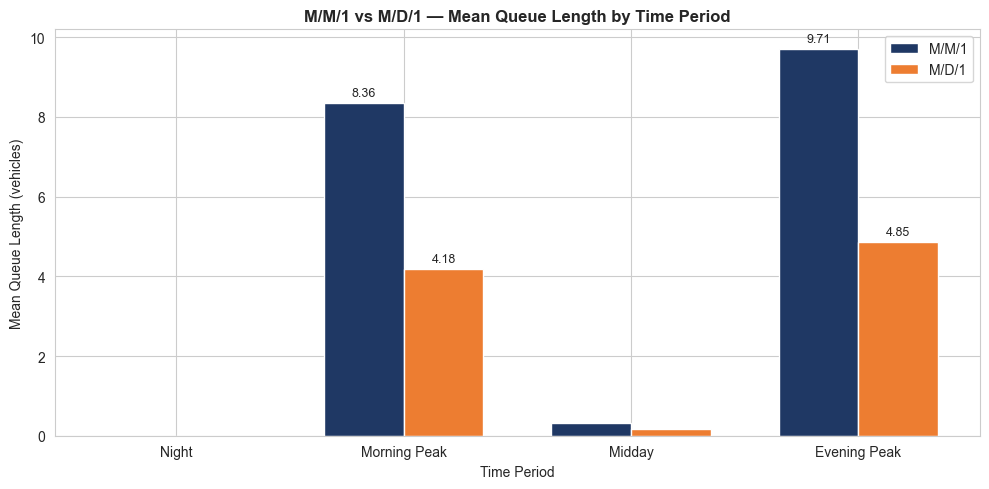

In [57]:
fig, ax = plt.subplots(figsize=(10, 5))

periods    = ['Night', 'Morning Peak', 'Midday', 'Evening Peak']
mm1_lq     = [0.0023, 8.3568, 0.3275, 9.7090]
md1_lq     = [0.0012, 4.1784, 0.1637, 4.8545]
x          = np.arange(len(periods))
width      = 0.35

bars1 = ax.bar(x - width/2, mm1_lq, width, label='M/M/1', color='#1F3864', edgecolor='white')
bars2 = ax.bar(x + width/2, md1_lq, width, label='M/D/1', color='#ED7D31', edgecolor='white')

ax.set_xlabel('Time Period')
ax.set_ylabel('Mean Queue Length (vehicles)')
ax.set_title('M/M/1 vs M/D/1 — Mean Queue Length by Time Period', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend()

for bar in bars1:
    if bar.get_height() > 0.5:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    if bar.get_height() > 0.5:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

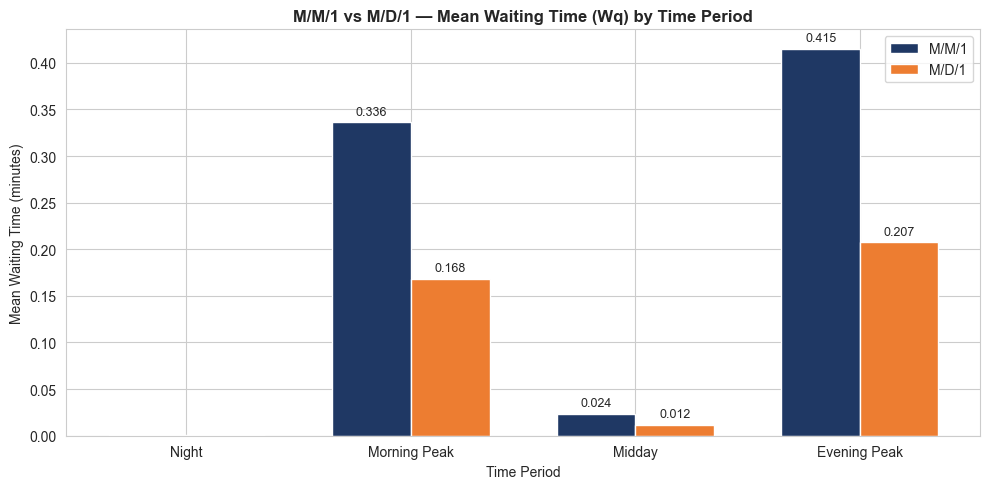

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))

mm1_wq = [0.0011, 0.3362, 0.0235, 0.4150]
md1_wq = [0.0006, 0.1681, 0.0117, 0.2075]

bars1 = ax.bar(x - width/2, mm1_wq, width, label='M/M/1', color='#1F3864', edgecolor='white')
bars2 = ax.bar(x + width/2, md1_wq, width, label='M/D/1', color='#ED7D31', edgecolor='white')

ax.set_xlabel('Time Period')
ax.set_ylabel('Mean Waiting Time (minutes)')
ax.set_title('M/M/1 vs M/D/1 — Mean Waiting Time (Wq) by Time Period', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend()

for bar in bars1:
    if bar.get_height() > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    if bar.get_height() > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

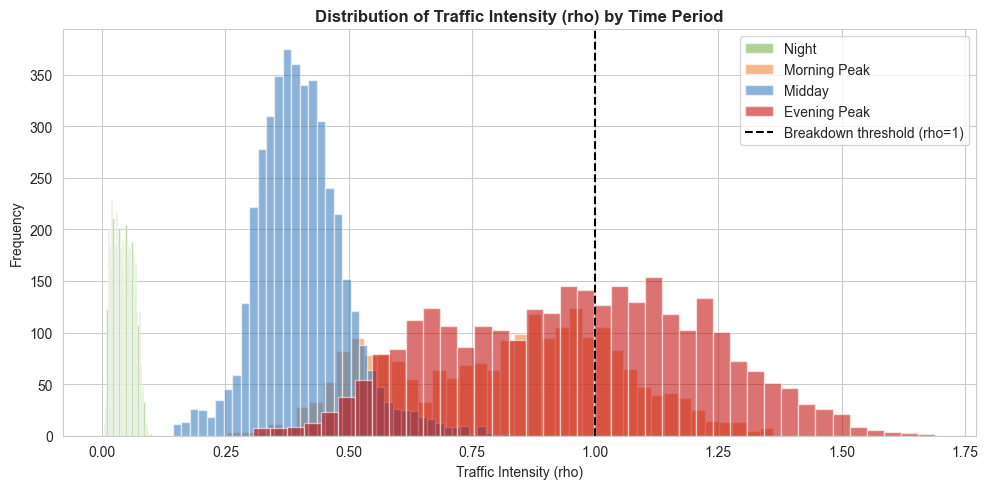

In [59]:
fig, ax = plt.subplots(figsize=(10, 5))

colors_map = {
    'Night':        '#70AD47',
    'Morning Peak': '#ED7D31',
    'Midday':       '#2E75B6',
    'Evening Peak': '#C00000'
}

for period in periods:
    sub = df[df['Time_Period'] == period]['rho']
    ax.hist(sub, bins=40, alpha=0.55, label=period,
            color=colors_map[period], edgecolor='white')

ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='Breakdown threshold (rho=1)')
ax.set_xlabel('Traffic Intensity (rho)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Traffic Intensity (rho) by Time Period', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

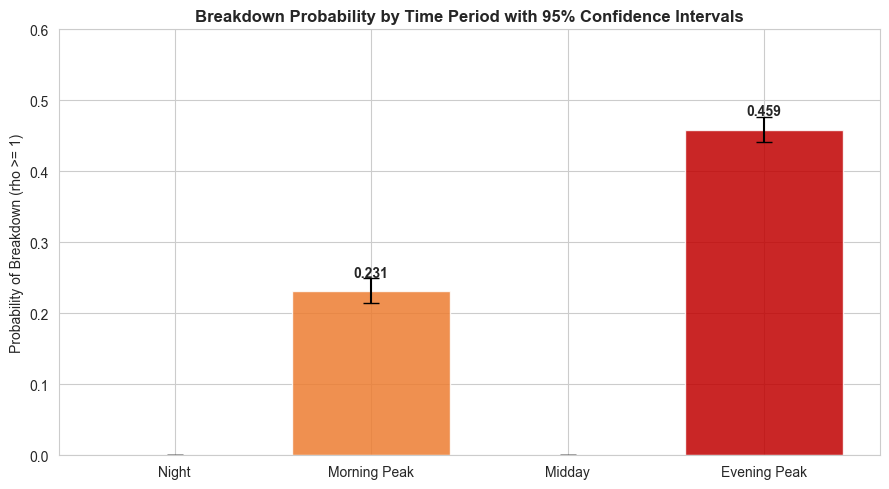

In [60]:
fig, ax = plt.subplots(figsize=(9, 5))

bd_probs  = [0.0000, 0.2312, 0.0000, 0.4588]
ci_lower  = [0.0000, 0.2140, 0.0000, 0.4408]
ci_upper  = [0.0008, 0.2494, 0.0009, 0.4769]
colors    = ['#70AD47', '#ED7D31', '#2E75B6', '#C00000']

yerr_lower = [bd_probs[i] - ci_lower[i] for i in range(4)]
yerr_upper = [ci_upper[i] - bd_probs[i] for i in range(4)]

bars = ax.bar(periods, bd_probs, color=colors, edgecolor='white', alpha=0.85)
ax.errorbar(periods, bd_probs,
            yerr=[yerr_lower, yerr_upper],
            fmt='none', color='black', capsize=6, linewidth=1.5)

ax.set_ylabel('Probability of Breakdown (rho >= 1)')
ax.set_title('Breakdown Probability by Time Period with 95% Confidence Intervals',
             fontweight='bold')
ax.set_ylim(0, 0.6)

for bar, val in zip(bars, bd_probs):
    if val > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

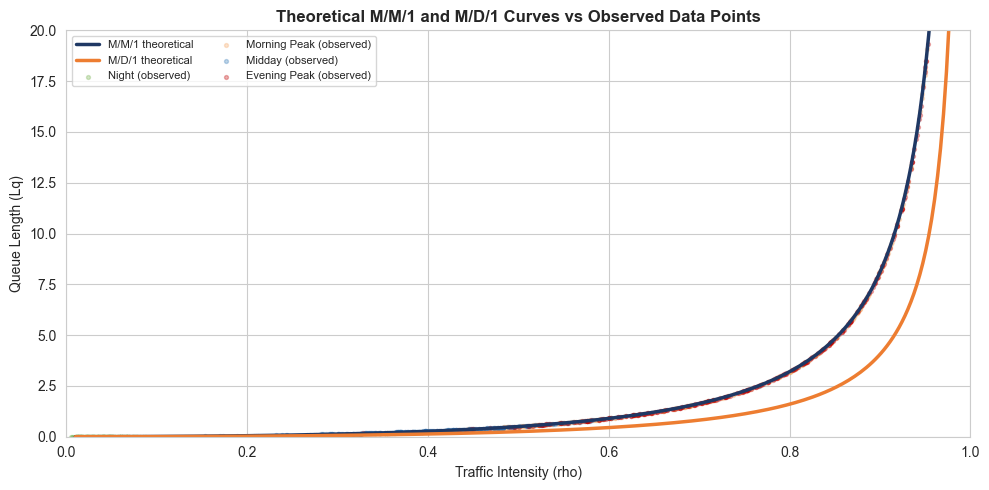

In [61]:
fig, ax = plt.subplots(figsize=(10, 5))

rho_range = np.linspace(0.01, 0.99, 300)
mm1_curve = rho_range ** 2 / (1 - rho_range)
md1_curve = rho_range ** 2 / (2 * (1 - rho_range))

ax.plot(rho_range, mm1_curve, color='#1F3864', linewidth=2.5, label='M/M/1 theoretical')
ax.plot(rho_range, md1_curve, color='#ED7D31', linewidth=2.5, label='M/D/1 theoretical')

# Overlay actual data points by time period
point_colors = {
    'Night':        '#70AD47',
    'Morning Peak': '#F4A460',
    'Midday':       '#2E75B6',
    'Evening Peak': '#C00000'
}

for period in periods:
    sub = df[(df['Time_Period'] == period) & (df['rho'] < 1)].sample(
        min(300, len(df[(df['Time_Period'] == period) & (df['rho'] < 1)])),
        random_state=42
    )
    ax.scatter(sub['rho'], sub['mm1_Lq_clean'],
               alpha=0.3, s=8, color=point_colors[period], label=f'{period} (observed)')

ax.set_xlim(0, 1)
ax.set_ylim(0, 20)
ax.set_xlabel('Traffic Intensity (rho)')
ax.set_ylabel('Queue Length (Lq)')
ax.set_title('Theoretical M/M/1 and M/D/1 Curves vs Observed Data Points', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

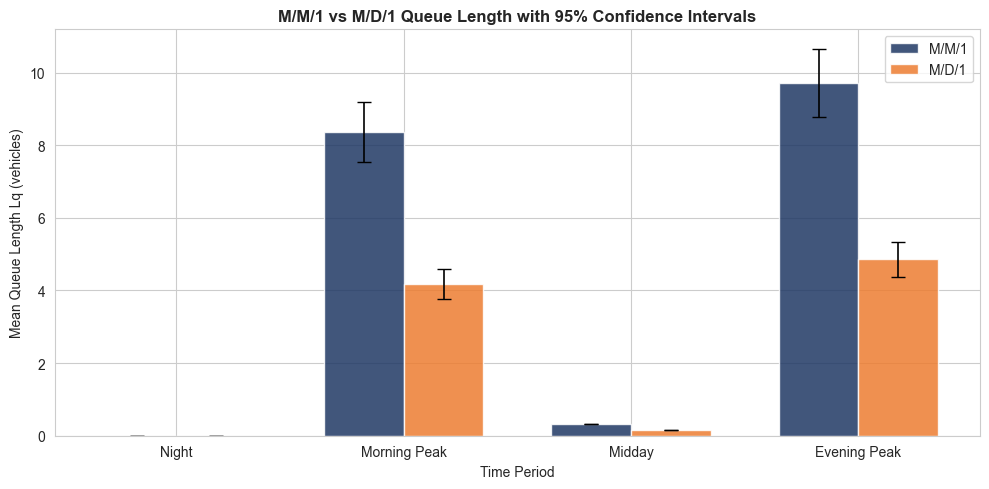

In [62]:
fig, ax = plt.subplots(figsize=(10, 5))

mm1_means  = [0.0023, 8.3568, 0.3275, 9.7090]
mm1_lower  = [0.0023, 7.5328, 0.3192, 8.7639]
mm1_upper  = [0.0024, 9.1808, 0.3357, 10.6540]

md1_means  = [0.0012, 4.1784, 0.1637, 4.8545]
md1_lower  = [0.0011, 3.7664, 0.1596, 4.3819]
md1_upper  = [0.0012, 4.5904, 0.1679, 5.3270]

x     = np.arange(len(periods))
width = 0.35

ax.bar(x - width/2, mm1_means, width, label='M/M/1',
       color='#1F3864', alpha=0.85, edgecolor='white')
ax.bar(x + width/2, md1_means, width, label='M/D/1',
       color='#ED7D31', alpha=0.85, edgecolor='white')

ax.errorbar(x - width/2, mm1_means,
            yerr=[
                [mm1_means[i] - mm1_lower[i] for i in range(4)],
                [mm1_upper[i] - mm1_means[i] for i in range(4)]
            ],
            fmt='none', color='black', capsize=5, linewidth=1.2)

ax.errorbar(x + width/2, md1_means,
            yerr=[
                [md1_means[i] - md1_lower[i] for i in range(4)],
                [md1_upper[i] - md1_means[i] for i in range(4)]
            ],
            fmt='none', color='black', capsize=5, linewidth=1.2)

ax.set_xlabel('Time Period')
ax.set_ylabel('Mean Queue Length Lq (vehicles)')
ax.set_title('M/M/1 vs M/D/1 Queue Length with 95% Confidence Intervals', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend()
plt.tight_layout()
plt.show()

In [1]:


print("=" * 65)
print("PROJECT CONCLUSIONS")
print("=" * 65)
print()
print("1. DISTRIBUTION FITTING")
print("   Arrival counts follow a Negative Binomial distribution")
print("   (99.8% subgroup pass rate). Poisson is rejected due to")
print("   inherent over-dispersion from day-to-day lambda variability.")
print("   Lambda estimates (period means) are used as queuing inputs.")
print()
print("2. SERVICE RATE (IRC 106)")
print("   mu ranges from 1,512 veh/hr (Evening Peak)")
print("   to 2,340 veh/hr (Night). Kathipara has highest demand.")
print()
print("3. TRAFFIC INTENSITY (rho)")
print("   Night: 0.042  |  Morning Peak: 0.730")
print("   Midday: 0.405  |  Evening Peak: 0.761")
print("   Kathipara Evening Peak mean rho = 1.05 (oversaturated).")
print("   10.54% of all records are breakdown conditions.")
print()
print("4. M/M/1 vs M/D/1")
print("   M/D/1 gives exactly half the queue length of M/M/1.")
print("   Paired t-test confirms significant difference (p < 0.001).")
print("   M/D/1 is the more realistic model for fixed-cycle signals.")
print()
print("5. STATISTICAL TESTING")
print("   ANOVA: rho differs significantly across periods (F=26531, p<0.001).")
print("   Tukey HSD: all 6 pairwise comparisons significant.")
print("   Wilson CI: Evening Peak breakdown probability = 0.459 (0.441-0.477).")
print()
print("6. RECOMMENDATIONS")
print("   - Extend green time at Kathipara & Koyambedu during Evening Peak.")
print("   - Implement adaptive signal control at peak junctions.")
print("   - Use M/D/1 as standard model for Chennai signal design.")
print("   - Demand-side interventions needed at Kathipara (rho > 1).")

PROJECT CONCLUSIONS

1. DISTRIBUTION FITTING
   Arrival counts follow a Negative Binomial distribution
   (99.8% subgroup pass rate). Poisson is rejected due to
   inherent over-dispersion from day-to-day lambda variability.
   Lambda estimates (period means) are used as queuing inputs.

2. SERVICE RATE (IRC 106)
   mu ranges from 1,512 veh/hr (Evening Peak)
   to 2,340 veh/hr (Night). Kathipara has highest demand.

3. TRAFFIC INTENSITY (rho)
   Night: 0.042  |  Morning Peak: 0.730
   Midday: 0.405  |  Evening Peak: 0.761
   Kathipara Evening Peak mean rho = 1.05 (oversaturated).
   10.54% of all records are breakdown conditions.

4. M/M/1 vs M/D/1
   M/D/1 gives exactly half the queue length of M/M/1.
   Paired t-test confirms significant difference (p < 0.001).
   M/D/1 is the more realistic model for fixed-cycle signals.

5. STATISTICAL TESTING
   ANOVA: rho differs significantly across periods (F=26531, p<0.001).
   Tukey HSD: all 6 pairwise comparisons significant.
   Wilson CI: E